# State of Data Brasil — Análise de Gênero (2021–2024)

## Seção 0 — Imports e Carregamento da base de dados

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, norm
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
import shap
from fairlearn.metrics import demographic_parity_difference
from sklearn.utils.class_weight import compute_sample_weight
                                

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

SEED  = 42
np.random.seed(SEED)
ALPHA = 0.05
print('OK')

c:\Users\julli\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OK


In [2]:
dfs_raw = {
    '2021': pd.read_csv('data/state_of_data_2021.csv', low_memory=False),
    '2022': pd.read_csv('data/state_of_data_2022.csv', low_memory=False),
    '2023': pd.read_csv('data/state_of_data_2023.csv', low_memory=False),
    '2024': pd.read_csv('data/state_of_data_2024.csv', low_memory=False),
}
for ano, df_raw in dfs_raw.items():
    print(f'{ano}: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')

2021: 2,645 linhas × 356 colunas
2022: 4,271 linhas × 353 colunas
2023: 5,293 linhas × 399 colunas
2024: 5,217 linhas × 403 colunas


### 0.1 Mapeamento de colunas por ano

In [3]:
COLUMN_MAPPING = {
    '2021': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_a ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_e ', 'Estado onde mora')",
        'uf':               "('P1_e_a ', 'uf onde mora')",
        'regiao':           "('P1_e_b ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_g_b ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_h ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_i ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_q ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2022': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_1 ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_i ', 'Estado onde mora')",
        'uf':               "('P1_i_1 ', 'uf onde mora')",
        'regiao':           "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_m ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_p ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2023': {
        'idade':            "('P1_a ', 'Idade')",
        'faixa_idade':      "('P1_a_1 ', 'Faixa idade')",
        'genero':           "('P1_b ', 'Genero')",
        'estado':           "('P1_i ', 'Estado onde mora')",
        'uf':               "('P1_i_1 ', 'uf onde mora')",
        'regiao':           "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':    "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':     "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':    "('P1_m ', 'Área de Formação')",
        'situacao':         "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':            "('P2_b ', 'Setor')",
        'cargo':            "('P2_f ', 'Cargo Atual')",
        'gestor':           "('P2_d ', 'Gestor?')",
        'nivel':            "('P2_g ', 'Nivel')",
        'faixa_salarial':   "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados': "('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':    "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':       "('P2_r ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2024': {
        'idade':            '1.a_idade',
        'faixa_idade':      '1.a.1_faixa_idade',
        'genero':           '1.b_genero',
        'estado':           '1.i_estado_onde_mora',
        'uf':               '1.i.1_uf_onde_mora',
        'regiao':           '1.i.2_regiao_onde_mora',
        'regiao_origem':    '1.k.2_regiao_de_origem',
        'nivel_ensino':     '1.l_nivel_de_ensino',
        'area_formacao':    '1.m_área_de_formação',
        'situacao':         '2.a_situação_de_trabalho',
        'setor':            '2.b_setor',
        'cargo':            '2.f_cargo_atual',
        'gestor':           '2.d_atua_como_gestor',
        'nivel':            '2.g_nivel',
        'faixa_salarial':   '2.h_faixa_salarial',
        'tempo_area_dados': '2.i_tempo_de_experiencia_em_dados',
        'tempo_area_ti':    '2.j_tempo_de_experiencia_em_ti',
        'modalidade':       '2.r_modelo_de_trabalho_atual',
    }
}

IA_COLS_RAW = {
    '2023': {
        'ia_prioridade_empresa':      "('P3_e ', 'AI Generativa é uma prioridade em sua empresa?')",
        'ia_tipos_uso_gestao':        "('P3_f ', 'Tipos de uso de AI Generativa e LLMs na empresa')",
        'ia_motivos_nao_usar':        "('P3_g ', 'Motivos que levam a empresa a não usar AI Genrativa e LLMs')",
        'ia_tipo_uso_pessoal':        "('P4_l ', 'Qual o tipo de uso de AI Generativa e LLMs na empresa')",
        'ia_usa_chatgpt_no_trabalho': "('P4_m ', 'Utiliza ChatGPT ou LLMs no trabalho?')",
    },
    '2024': {
        'ia_prioridade_empresa':      '3.e_ai_generativa_e_llm_é_uma_prioridade?',
        'ia_tipos_uso_gestao':        '3.f_tipo_de_uso_de_ai_generativa_e_llm_na_empresa',
        'ia_motivos_nao_usar':        '3.g_motivos_para_não_usar_ai_generativa_e_llm',
        'ia_tipo_uso_pessoal':        '4.l_tipo_de_uso_de_ai_generativa_e_llm_na_empresa',
        'ia_usa_chatgpt_no_trabalho': '4.m_usa_chatgpt_ou_copilot_no_trabalho?',
    },
}


### 0.2 Mapeamentos ordinais e de categorias

In [4]:
FAIXA_SALARIAL_MAP = {
    'de R$ 1.001/mês a R$ 2.000/mês':   'R$1k-2k',
    'de R$ 2.001/mês a R$ 3.000/mês':   'R$2k-3k',
    'de R$ 2.001/mês a R$ 3000/mês':    'R$2k-3k',
    'de R$ 3.001/mês a R$ 4.000/mês':   'R$3k-4k',
    'de R$ 4.001/mês a R$ 6.000/mês':   'R$4k-6k',
    'de R$ 6.001/mês a R$ 8.000/mês':   'R$6k-8k',
    'de R$ 8.001/mês a R$ 12.000/mês':  'R$8k-12k',
    'de R$ 12.001/mês a R$ 16.000/mês': 'R$12k-16k',
    'de R$ 16.001/mês a R$ 20.000/mês': 'R$16k-20k',
    'de R$ 20.001/mês a R$ 25.000/mês': 'R$20k-25k',
    'de R$ 25.001/mês a R$ 30.000/mês': 'R$25k-30k',
    'de R$ 30.001/mês a R$ 40.000/mês': 'R$30k-40k',
    'Acima de R$ 40.001/mês':           'R$40k+',
}
FAIXA_SALARIAL_ORDEM = [
    'R$1k-2k', 'R$2k-3k', 'R$3k-4k', 'R$4k-6k', 'R$6k-8k',
    'R$8k-12k', 'R$12k-16k', 'R$16k-20k', 'R$20k-25k',
    'R$25k-30k', 'R$30k-40k', 'R$40k+',
]
NIVEL_ENSINO_ORDEM = [
    'Não tenho graduação formal', 'Estudante de Graduação',
    'Graduação/Bacharelado', 'Especialização Lato Sensu',
    'Mestrado', 'Doutorado ou Phd',
]
#NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior', 'Gestor']
NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior']  # leakage
NIVEL_SENIORIDADE_EDA    = ['Júnior', 'Pleno', 'Sênior', 'Gestor']  # EDA

TEMPO_AREA_DADOS_MAP = {
    'Não tenho experiência na área de dados': 0.0,
    'Menos de 1 ano':   0.5,
    'de 1 a 2 anos':    1.5,
    'de 2 a 3 anos':    2.5,
    'de 3 a 4 anos':    3.5,
    'de 4 a 5 anos':    4.5,
    'de 4 a 6 anos':    5.0,
    'de 5 a 6 anos':    5.5,
    'de 6 a 10 anos':   8.0,
    'de 7 a 10 anos':   8.5,
    'Mais de 10 anos':  12.0,
}
TEMPO_AREA_DADOS_ORDEM = list(TEMPO_AREA_DADOS_MAP.keys())

CARGO_MAP = {
    'Analista de Dados/Data Analyst':                    'Analista de Dados',
    'Analista de BI/BI Analyst':                         'Analista de Dados',
    'Analista de BI/BI Analyst/Analytics Engineer':      'Analista de Dados',
    'Analista de Negócios/Business Analyst':             'Analista de Dados',
    'Analista de Inteligência de Mercado/Market Intelligence': 'Analista de Dados',
    'Analista de Marketing':                             'Analista de Dados',
    'Analista Administrativo':                           'Analista de Dados',
    'Estatístico':                                       'Analista de Dados',
    'Economista':                                        'Analista de Dados',
    'Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect': 'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer':                 'Engenheiro de Dados',
    'Analytics Engineer':                                'Engenheiro de Dados',
    'Arquiteto de Dados':                                'Engenheiro de Dados',
    'Arquiteto de dados':                                'Engenheiro de Dados',
    'DBA/Administrador de Banco de Dados':               'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect':  'Engenheiro de Dados',
    'Arquiteto de Dados/Data Architect':                 'Engenheiro de Dados',
    'Cientista de Dados/Data Scientist':                 'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer':        'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer': 'Cientista de Dados',
    'Professor':                                         'Professor/Pesquisador',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Product Manager/ Product Owner (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas': 'Desenvolvedor',
    'Desenvolvedor ou Engenheiro de Software':           'Desenvolvedor',
    'Analista de Sistemas/Analista de TI':               'Desenvolvedor',
    'Analista de Suporte/Analista Técnico':              'Desenvolvedor',
    'Suporte Técnico':                                   'Desenvolvedor',
    'Técnico':                                           'Desenvolvedor',
    'Outra Opção':                                       'Outro',
    'Outras Engenharias (não inclui dev)':               'Outro',
}
AREA_FORMACAO_MAP = {
    'Computação / Engenharia de Software / Sistemas de Informação/ TI': 'Computação / TI',
    'Outras Engenharias': 'Engenharia (outras)',
    'Outras Engenharias (não incluir engenharia de software ou TI)': 'Engenharia (outras)',
    'Economia/ Administração / Contabilidade / Finanças/ Negócios': 'Economia / Adm / Finanças',
    'Economia/ Administração / Contabilidade / Finanças': 'Economia / Adm / Finanças',
    'Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais': 'Estatística / Matemática',
    'Estatística/ Matemática / Matemática Computacional': 'Estatística / Matemática',
    'Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde': 'Ciências da Saúde',
    'Ciências Biológicas/Farmácia/Medicina/Área da Saúde': 'Ciências da Saúde',
    'Marketing / Publicidade / Comunicação / Jornalismo': 'Marketing / Comunicação',
    'Marketing / Publicidade / Comunicação / Jornalismo / Ciências Sociais': 'Marketing / Comunicação',
    'Outra opção': 'Outras',
}
SITUACAO_MAP = {
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil':      'Remoto p/ exterior',
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil (PJ)': 'Remoto p/ exterior',
    'Desempregado, buscando recolocação':                                   'Desempregado',
    'Desempregado e não estou buscando recolocação':                        'Desempregado',
    'Somente Estudante (graduação)':                                        'Somente Estudante',
    'Somente Estudante (pós-graduação)':                                    'Somente Estudante',
    'Prefiro não informar':                                                  None,
}

REGIAO_MAP = {
    'Centro_Oeste': 'Centro-Oeste', 'Centro Oeste': 'Centro-Oeste',
    'centro-oeste': 'Centro-Oeste', 'Centro-oeste': 'Centro-Oeste',
    'nordeste': 'Nordeste', 'norte': 'Norte',
    'sudeste': 'Sudeste',  'sul':    'Sul',
    'Exterior': None, 'Prefiro não informar': None,
}

MODALIDADE_MAP = {
    'Modelo 100% presencial': 'Presencial',
    'Modelo 100% remoto': 'Remoto',
    'Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)': 'Híbrido flexível',
    'Modelo híbrido com dias fixos de trabalho presencial': 'Híbrido fixo',
}

ANOS     = ['2021', '2022', '2023', '2024']
REGIOES = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']

CORES_GENERO = {'Masculino': '#517493', 'Feminino': '#64313E'}
CORES_REGIAO = {
    'Sudeste':      '#2563EB',
    'Sul':          '#16A34A',
    'Nordeste':     '#EA580C',
    'Centro-Oeste': '#9333EA',
    'Norte':        '#CA8A04',
}
TEMPLATE = 'plotly_white'

In [5]:
# ia_usa_chatgpt_no_trabalho
_NAO_USA       = 'Não utilizo nenhum tipo de solução de IA Generativa'
_USA_GRATUITA  = 'Utilizo apenas soluções gratuitas'
_USA_PAGA_PROP = 'pago do meu próprio bolso'
_USA_PAGA_EMP  = 'a empresa em que trabalho paga'
_USA_COPILOT   = 'Copilot'

# ia_prioridade_empresa
_PRIORIDADE_ALTA = [
    'Sim, é nossa principal prioridade',
    'Sim, está entre nossas principais prioridades',
]

# ia_tipo_uso_pessoal / ia_tipos_uso_gestao
_ORG_COLABORADORES = 'Colaboradores utilizando soluções baseadas em AI Generativa'


def engenharia_ia(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria features binárias relacionadas ao uso individual e organizacional
    de IA generativa, preservando a distinção entre ausência de resposta
    e pergunta inexistente no ano da pesquisa.
    """
    df = df.copy()

    # ------------------------------------------------------------------
    # 1. Uso individual de IA
    # ------------------------------------------------------------------

    col = 'ia_usa_chatgpt_no_trabalho'

    flags_uso = {
        'ia_nao_usa':       _NAO_USA,
        'ia_usa_gratuita':  _USA_GRATUITA,
        'ia_usa_paga_prop': _USA_PAGA_PROP,
        'ia_usa_paga_emp':  _USA_PAGA_EMP,
        'ia_usa_copilot':   _USA_COPILOT,
    }

    s = df[col].fillna('')
    sem_dados = df[col].isna()

    for nova_col, padrao in flags_uso.items():
        df[nova_col] = s.str.contains(padrao, na=False).astype('Int8')
        df.loc[sem_dados, nova_col] = pd.NA

    # ------------------------------------------------------------------
    # 2. IA como prioridade estratégica da empresa
    # ------------------------------------------------------------------

    col_pri = 'ia_prioridade_empresa'

    if col_pri in df.columns:
        s_pri = df[col_pri].fillna('')

        df['ia_empresa_prioridade_alta'] = (
            s_pri.apply(
                lambda x: (
                    1 if any(p in x for p in _PRIORIDADE_ALTA)
                    else pd.NA if x == ''
                    else 0
                )
            )
            .astype('Int8')
        )
    else:
        df['ia_empresa_prioridade_alta'] = pd.Series(pd.NA, index=df.index, dtype='Int8')

    # ------------------------------------------------------------------
    # 3. Uso difuso na organização
    # ------------------------------------------------------------------

    col_tp = 'ia_tipo_uso_pessoal'
    col_tg = 'ia_tipos_uso_gestao'

    s_org = pd.Series('', index=df.index)

    if col_tp in df.columns:
        s_org += df[col_tp].fillna('')

    if col_tg in df.columns:
        s_org += df[col_tg].fillna('')

    sem_org = (
        df.get(col_tp, pd.Series(pd.NA, index=df.index)).isna()
        &
        df.get(col_tg, pd.Series(pd.NA, index=df.index)).isna()
    )

    df['ia_org_uso_difuso'] = (
        s_org.str.contains(_ORG_COLABORADORES, na=False)
        .astype('Int8')
    )

    df.loc[sem_org, 'ia_org_uso_difuso'] = pd.NA

    return df

In [6]:
IA_FEATURES_MODELO_B = [
    'ia_nao_usa',
    'ia_usa_gratuita',
    'ia_usa_paga_prop',
    'ia_usa_paga_emp',
    'ia_usa_copilot',
    'ia_empresa_prioridade_alta',
    'ia_org_uso_difuso',
]

In [7]:
# Labels legíveis para SHAP / gráficos
IA_FEATURE_LABELS = {
    'ia_nao_usa':                  'Não usa IA',
    'ia_usa_gratuita':             'Usa IA gratuita',
    'ia_usa_paga_prop':            'Usa IA paga (bolso próprio)',
    'ia_usa_paga_emp':             'Usa IA paga (empresa paga)',
    'ia_usa_copilot':              'Usa Copilot',
    'ia_empresa_prioridade_alta':  'IA é prioridade alta na empresa',
    'ia_org_uso_difuso':           'Uso difuso na organização',
}

---
## Seção 1 — Pipeline de pré-processamento

In [8]:
def build_year_dataframe(df_raw: pd.DataFrame, year: str) -> pd.DataFrame:
    base_map = COLUMN_MAPPING[year]
    cols_base = {old: new for new, old in base_map.items() if old in df_raw.columns}
    df = df_raw[list(cols_base.keys())].rename(columns=cols_base).copy()

    if year in IA_COLS_RAW:
        ia_map = IA_COLS_RAW[year]
        cols_ia = {old: new for new, old in ia_map.items() if old in df_raw.columns}
        df = pd.concat([df, df_raw[list(cols_ia.keys())].rename(columns=cols_ia)], axis=1)

    df.insert(0, 'ano_pesquisa', year)
    return df


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df[df['genero'].isin(['Masculino', 'Feminino'])].copy()

    df['nivel_ensino'] = df['nivel_ensino'].replace({'Pós-graduação': 'Especialização Lato Sensu', 'Prefiro não informar': np.nan})
    df['nivel_ensino'] = pd.Categorical(df['nivel_ensino'], categories=NIVEL_ENSINO_ORDEM, ordered=True)

    df['faixa_salarial'] = df['faixa_salarial'].str.replace(r'\s+', ' ', regex=True).str.strip().replace(FAIXA_SALARIAL_MAP)
    df['faixa_salarial'] = pd.Categorical(df['faixa_salarial'], categories=FAIXA_SALARIAL_ORDEM, ordered=True)

    df['cargo']        = df['cargo'].replace(CARGO_MAP)
    df['area_formacao']= df['area_formacao'].replace(AREA_FORMACAO_MAP)
    df['regiao']       = df['regiao'].replace(REGIAO_MAP)
    df['modalidade']   = df['modalidade'].map(MODALIDADE_MAP).fillna(df['modalidade'])

    df['tempo_area_dados'] = pd.Categorical(
    df['tempo_area_dados'], categories=TEMPO_AREA_DADOS_ORDEM, ordered=True)
    df['tempo_area_dados_anos'] = df['tempo_area_dados'].map(TEMPO_AREA_DADOS_MAP).astype(float)

    df['nivel'] = pd.Categorical(
        df['nivel'].where(df['nivel'].isin(NIVEL_SENIORIDADE_ORDEM)),
        categories=NIVEL_SENIORIDADE_ORDEM, ordered=True
    )

    # NaN mantido: distinto de "não é gestor"
    df['gestor'] = df['gestor'].replace({'Sim': 1, 'Não': 0, 'sim': 1, 'não': 0}).pipe(pd.to_numeric, errors='coerce')

    df['situacao'] = df['situacao'].replace(SITUACAO_MAP)
    df = df[df['situacao'].notna()]
    df = df[~df['situacao'].isin(['Desempregado', 'Somente Estudante'])]

    return df.reset_index(drop=True)

def criar_targets_salariais(df: pd.DataFrame) -> pd.DataFrame:
    """Cria versões agrupadas da faixa salarial para experimento de sensibilidade."""
    df = df.copy()

    ALTA   = ['R$12k-16k', 'R$16k-20k', 'R$20k-25k', 'R$25k-30k', 'R$30k-40k', 'R$40k+']
    MEDIA  = ['R$6k-8k', 'R$8k-12k']
    # Baixa = demais

    def agrupa_3(fx):
        if pd.isna(fx):   return np.nan
        if fx in ALTA:    return 'Alta'
        if fx in MEDIA:   return 'Média'
        return 'Baixa'

    df['faixa_salarial_3']   = df['faixa_salarial'].apply(agrupa_3)
    df['faixa_salarial_bin'] = (df['faixa_salarial'].isin(ALTA)).astype('Int8')
    df.loc[df['faixa_salarial'].isna(), 'faixa_salarial_bin'] = pd.NA

    return df


def run_pipeline(dfs_raw: dict) -> pd.DataFrame:
    frames = [build_year_dataframe(dfs_raw[year], year) for year in ANOS]
    df = pd.concat(frames, ignore_index=True)
    df = preprocess(df)
    df = engenharia_ia(df)
    return df


df = run_pipeline(dfs_raw)
print(f'Dataset completo: {df.shape}')

Dataset completo: (15796, 32)


In [9]:
# Split temporal: treino (2021–2023) e teste (2024)
df_train = df[df['ano_pesquisa'] != '2024'].copy()
df_test  = df[df['ano_pesquisa'] == '2024'].copy()

# Persistência dos datasets
df.to_parquet('data/df_full.parquet', index=False)
df_train.to_parquet('data/df_train.parquet', index=False)
df_test.to_parquet('data/df_test.parquet', index=False)


print(
    f'Full: {df.shape} | '
    f'Treino: {df_train.shape} | '
    f'Teste: {df_test.shape}'
)

print(
    f'Cobertura IA — '
    f'Treino: {df_train[IA_FEATURES_MODELO_B].notna().any(axis=1).mean()*100:.1f}% | '
    f'Teste: {df_test[IA_FEATURES_MODELO_B].notna().any(axis=1).mean()*100:.1f}%'
)

Full: (15796, 32) | Treino: (10925, 32) | Teste: (4871, 32)
Cobertura IA — Treino: 42.5% | Teste: 94.9%


---
## Seção 2 — Análise Exploratória de Dados EDA

Cada visualização responde uma pergunta diferente, todas longitudinais por ano sem agregação e sem redundância. 

- 2.1 Representatividade feminina ao longo dos anos
- 2.2 Senioridade por gênero
- 2.3 Distribuição de cargos por gênero
- 2.4 Diferença salarial entre gêneros
- 2.5 Escolaridade por gênero
- 2.6 Área de formação por gênero
- 2.7 Distribuição de Experiência na Área de Dados por Gênero
- 2.8 Modalidade de trabalho por gênero
- 2.9 Adoção de IA por gênero
- 2.10 Análise regional da participação feminina


### 2.0 Config

In [10]:
def fmt(fig, title, height=450, **kw):
    fig.update_layout(
        title=title,
        template=TEMPLATE,
        height=height,
        legend=dict(orientation='h', y=1.02, x=1, xanchor='right'),
        **kw,
    )
    return fig
 
 
def dedup_legend(fig):
    seen = set()
    for t in fig.data:
        t.showlegend = t.name not in seen
        seen.add(t.name)
    return fig
 
 
def subplots_pct_fem(df, col, order, title, height=420):
    """
    Subplots 1×4 (um por ano): % feminino por categoria.
    - % do gênero feminino dentro de cada categoria sobreposto na barra (cor branca, bold)
    - n total da categoria exibido fora da barra
    - range do eixo X calculado dinamicamente (máx + margem de 15 pp)
    """
    # calcula range dinâmico
    tab_all = pd.crosstab(df[col], df['genero']).reindex(order).fillna(0)
    n_all   = tab_all.sum(axis=1)
    pct_max = (tab_all.get('Feminino', 0) / n_all.replace(0, np.nan) * 100).max()
    x_max   = min(100, np.ceil((pct_max + 15) / 10) * 10)
 
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)
 
    for i, ano in enumerate(ANOS, 1):
        sub = df[df['ano_pesquisa'] == ano]
        tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
        n   = tab.sum(axis=1)
        pct = tab.get('Feminino', pd.Series(0, index=tab.index)) / n.replace(0, np.nan) * 100
 
        # texto dentro da barra: % (branco, negrito visual via tamanho)
        text_inside = [
            f'<b>{v:.0f}%</b>' if not np.isnan(v) else ''
            for v in pct
        ]
        # texto fora da barra: n total
        text_outside = [f'n={int(ni)}' for ni in n]
 
        # barra principal com % dentro
        fig.add_trace(go.Bar(
            y=pct.index,
            x=pct.values,
            orientation='h',
            marker_color=CORES_GENERO['Feminino'],
            text=text_inside,
            textposition='inside',
            textfont=dict(color='white', size=11),
            showlegend=False,
            customdata=n.values,
            hovertemplate='%{y}: %{x:.1f}% feminino (n=%{customdata})<extra></extra>',
        ), row=1, col=i)
 
        # marcadores invisíveis para exibir n fora da barra
        fig.add_trace(go.Scatter(
            y=pct.index,
            x=pct.values,
            mode='text',
            text=text_outside,
            textposition='middle right',
            textfont=dict(size=9, color='gray'),
            showlegend=False,
        ), row=1, col=i)
 
        fig.update_xaxes(range=[0, x_max], ticksuffix='%', row=1, col=i)
 
    return fmt(fig, title, height=height)
 
 
def subplots_piramide(df, col, order, title, height=420):
    """
    Subplots 1×4: pirâmide bilateral — % dentro de cada gênero por categoria.
    Feminino à esquerda (negativo), Masculino à direita.
    Ordem da legenda: Feminino primeiro.
    """
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)
 
    # Feminino sempre primeiro para fixar ordem da legenda
    for genero in ['Feminino', 'Masculino']:
        for i, ano in enumerate(ANOS, 1):
            sub = df[df['ano_pesquisa'] == ano]
            tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
            pct = tab.div(tab.sum(), axis=1) * 100

            vals = pct.get(genero, pd.Series(0, index=pct.index))
            x    = -vals if genero == 'Feminino' else vals

            fig.add_trace(go.Bar(
                y=pct.index,
                x=x,
                orientation='h',
                name=genero,
                legendgroup=genero,
                marker_color=CORES_GENERO[genero],
                text=[f'{v:.0f}%' for v in vals],
                textposition='auto',
                textfont=dict(color='white', size=10),
            ), row=1, col=i)

    # Linha central e eixos aplicados uma vez por subplot, fora do loop de gênero
    for i in range(1, len(ANOS) + 1):
        fig.add_shape(
            type='line', x0=0, x1=0,
            y0=-0.5, y1=len(order) - 0.5,
            line=dict(color='black', dash='dot', width=1),
            row=1, col=i,
        )
        fig.update_xaxes(
            range=[-60, 60],
            tickvals=[-40, -20, 0, 20, 40],
            ticktext=['40%', '20%', '0', '20%', '40%'],
            row=1, col=i,
        )

    dedup_legend(fig)
    return fmt(fig, title, height=height, barmode='relative')

### 2.1 — Representatividade feminina ao longo dos anos



In [11]:
tab = pd.crosstab(df['ano_pesquisa'], df['genero']).reindex(ANOS)
pct_fem = tab['Feminino'].div(tab.sum(axis=1)).mul(100)
 
fig = go.Figure(go.Scatter(
    x=ANOS,
    y=pct_fem,
    mode='lines+markers+text',
    text=[
        f'<b>{v:.1f}%</b><br><sup>n={int(n)}</sup>'
        for v, n in zip(pct_fem, tab.sum(axis=1))
    ],
    textposition='top center',
    line=dict(color=CORES_GENERO['Feminino'], width=3),
    marker=dict(size=10),
))
 
fig = fmt(fig, 'Representatividade Feminina por Ano (2021–2024)', height=360)
fig.update_yaxes(title='% Feminino', ticksuffix='%', range=[0, 40])
fig.show()


### 2.2 — Senioridade por gênero



In [12]:
fig = subplots_piramide(
    df, 'nivel', NIVEL_SENIORIDADE_EDA,
    'Senioridade por Gênero (2021–2024)',
)
fig.show()


### 2.3 — Cargo por gênero

In [13]:
CARGO_ORDEM = [
    'Analista de Dados',
    'Cientista de Dados',
    'Engenheiro de Dados',
    'Desenvolvedor',
    'Product Manager',
    'Professor/Pesquisador',
    'Outro',
]
 
fig = subplots_pct_fem(
    df, 'cargo', CARGO_ORDEM,
    '% Feminino por Cargo (2021–2024)',
    height=440,
)
fig.show()



### 2.4 — Distribuição salarial por gênero

In [14]:
fig = subplots_piramide(
    df, 'faixa_salarial', FAIXA_SALARIAL_ORDEM,
    'Distribuição Salarial por Gênero — % dentro de cada gênero (2021–2024)',
    height=560,
)
fig.show()


### 2.5 — Escolaridade por gênero

In [15]:
fig = subplots_pct_fem(
    df, 'nivel_ensino', NIVEL_ENSINO_ORDEM,
    '% Feminino por Nível de Ensino (2021–2024)',
    height=440,
)
fig.show()



In [16]:
# Distribuição de escolaridade dentro de cada gênero (% por nível)
tab_ens = pd.crosstab(df['nivel_ensino'], df['genero'])
tab_ens_pct = tab_ens.div(tab_ens.sum(axis=0), axis=1) * 100
tab_ens_pct = tab_ens_pct.reindex(NIVEL_ENSINO_ORDEM)

fig = go.Figure()
for genero in ['Feminino', 'Masculino']:
    fig.add_trace(go.Bar(
        name=genero,
        x=tab_ens_pct.index,
        y=tab_ens_pct[genero],
        marker_color=CORES_GENERO[genero],
        text=[f"{v:.1f}%" for v in tab_ens_pct[genero]],
        textposition='outside',
    ))
fig = fmt(
    fig,
    'Distribuição de Escolaridade por Gênero (% dentro de cada gênero)',
    height=420,
    barmode='group',
)
fig.update_yaxes(title='%', ticksuffix='%')
fig.show()


### 2.6 — Área de formação por gênero

In [17]:
AREA_ORDEM = [
    'Computação / TI',
    'Engenharia (outras)',
    'Estatística / Matemática',
    'Economia / Adm / Finanças',
    'Ciências da Saúde',
    'Marketing / Comunicação',
    'Outras',
]
 
fig = subplots_pct_fem(
    df, 'area_formacao', AREA_ORDEM,
    '% Feminino por Área de Formação (2021–2024)',
    height=440,
)
fig.show()


### 2.7 — Experiência na área de dados por gênero

In [18]:
EXPERIENCIA_FAIXA_BINS = [-0.01, 0, 1, 3, 5, 7, 10, np.inf]
EXPERIENCIA_FAIXA_LABELS = [
    'Sem experiência', 'Até 1 ano', '1 a 3 anos', '3 a 5 anos',
    '5 a 7 anos', '7 a 10 anos', 'Mais de 10 anos',
]

df['experiencia_faixa'] = pd.cut(
    df['tempo_area_dados_anos'], bins=EXPERIENCIA_FAIXA_BINS,
    labels=EXPERIENCIA_FAIXA_LABELS, right=True,
)

cobertura_exp = pd.crosstab(df['experiencia_faixa'], df['ano_pesquisa']).reindex(EXPERIENCIA_FAIXA_LABELS)
print('Cobertura de experiencia_faixa por ano:')
print(cobertura_exp)
print()
print("Nota: '5 a 7 anos' com 0 em 2021/2022 reflete o instrumento da pesquisa "
      "daqueles anos (nenhuma faixa bruta caía nesse intervalo), não ausência de dado.")

fig = subplots_pct_fem(
    df[df['experiencia_faixa'].notna()],
    'experiencia_faixa',
    EXPERIENCIA_FAIXA_LABELS,
    '% Feminino por Tempo de Experiência em Dados (2021–2024)',
    height=440,
)
fig.show()

Cobertura de experiencia_faixa por ano:
ano_pesquisa       2021  2022  2023  2024
experiencia_faixa                        
Sem experiência     121   181   158   220
Até 1 ano           381   586   472   342
1 a 3 anos          928   968  1196   935
3 a 5 anos          387  1229  1563  1377
5 a 7 anos            0     0   355   827
7 a 10 anos         276   293   428   538
Mais de 10 anos     261   397   551   576

Nota: '5 a 7 anos' com 0 em 2021/2022 reflete o instrumento da pesquisa daqueles anos (nenhuma faixa bruta caía nesse intervalo), não ausência de dado.


### 2.8 — Modalidade de trabalho por gênero

In [19]:
MODALIDADE_ORDEM = ['Remoto', 'Híbrido flexível', 'Híbrido fixo', 'Presencial']

fig = subplots_pct_fem(
    df[df['modalidade'].notna()], 'modalidade', MODALIDADE_ORDEM,
    '% Feminino por Modalidade de Trabalho (2021–2024)',
    height=400,
)
fig.show()

In [20]:
def subplots_pct_genero(df, col, order, title, height=420):
    """
    Subplots 1×4 (um por ano): % Feminino e % Masculino por categoria,
    empilhados numa única barra (soma ≈ 100%) — o masculino funciona
    como complemento visual direto do feminino.
    """
    fig = make_subplots(1, 4, subplot_titles=ANOS, shared_yaxes=True)

    for i, ano in enumerate(ANOS, 1):
        sub = df[df['ano_pesquisa'] == ano]
        tab = pd.crosstab(sub[col], sub['genero']).reindex(order).fillna(0)
        n   = tab.sum(axis=1)
        pct_f = tab.get('Feminino',  pd.Series(0, index=tab.index)) / n.replace(0, np.nan) * 100
        pct_m = tab.get('Masculino', pd.Series(0, index=tab.index)) / n.replace(0, np.nan) * 100

        for genero, pct in [('Feminino', pct_f), ('Masculino', pct_m)]:
            fig.add_trace(go.Bar(
                y=tab.index, x=pct, orientation='h',
                name=genero, legendgroup=genero,
                marker_color=CORES_GENERO[genero],
                text=[f'<b>{v:.0f}%</b>' if not np.isnan(v) else '' for v in pct],
                textposition='inside', textfont=dict(color='white', size=10),
                showlegend=(i == 1),
            ), row=1, col=i)

        eixo = '' if i == 1 else str(i)
        for yi, ni in zip(tab.index, n):
            fig.add_annotation(
                x=103, y=yi, text=f'n={int(ni)}', showarrow=False,
                xref=f'x{eixo}', yref=f'y{eixo}',
                font=dict(size=9, color='gray'), xanchor='left',
            )

    fig.update_xaxes(range=[0, 118], ticksuffix='%')
    fig = fmt(fig, title, height=height, barmode='stack')
    return fig


MODALIDADE_ORDEM = ['Remoto', 'Híbrido flexível', 'Híbrido fixo', 'Presencial']

fig = subplots_pct_genero(
    df[df['modalidade'].notna()], 'modalidade', MODALIDADE_ORDEM,
    '% Feminino e Masculino por Modalidade de Trabalho (2021–2024)',
    height=400,
)
fig.show()

### 2.9 — Adoção de IA generativa por gênero 

In [21]:
ANOS_IA = ['2023', '2024']
df_ia   = df[df['ano_pesquisa'].isin(ANOS_IA)].copy()

rows = []
for ano in ANOS_IA:
    sub_ano = df_ia[df_ia['ano_pesquisa'] == ano]
    for feat in IA_FEATURES_MODELO_B:
        for genero in ['Feminino', 'Masculino']:
            s = sub_ano.loc[sub_ano['genero'] == genero, feat].dropna()
            if len(s) == 0:
                continue
            rows.append({
                'ano_pesquisa': ano,
                'Feature':      IA_FEATURE_LABELS.get(feat, feat),
                'genero':       genero,
                'pct':          s.mean() * 100,
                'n':            len(s),
            })
df_ia_eda = pd.DataFrame(rows)

fig = go.Figure()
for genero in ['Feminino', 'Masculino']:
    sub = df_ia_eda[df_ia_eda['genero'] == genero]
    fig.add_trace(go.Bar(
        x=[sub['Feature'], sub['ano_pesquisa']],
        y=sub['pct'],
        name=genero,
        marker_color=CORES_GENERO[genero],
        text=[f'{v:.1f}%' for v in sub['pct']],
        textposition='outside',
    ))
fig = fmt(fig, 'Adoção de IA Generativa por Gênero (2023–2024) — visão exploratória',
          height=480, barmode='group')
fig.update_yaxes(title='% que reporta a característica', ticksuffix='%', range=[0, 110])
fig.update_xaxes(tickangle=25)
fig.show()

print('Nota: teste estatístico formal (χ², V de Cramér, IC 95% Wilson) e o gráfico '
      'confirmatório com intervalos de confiança estão consolidados na Seção 3.5 — H6.')


Nota: teste estatístico formal (χ², V de Cramér, IC 95% Wilson) e o gráfico confirmatório com intervalos de confiança estão consolidados na Seção 3.5 — H6.


### 2.10 — Representatividade feminina por região

In [22]:
df_reg = df[df['regiao'].isin(REGIOES)].copy()

fig = go.Figure()
for regiao in REGIOES:
    pcts, textos = [], []
    for ano in ANOS:
        sub = df_reg[(df_reg['regiao'] == regiao) & (df_reg['ano_pesquisa'] == ano)]
        ct  = sub['genero'].value_counts()
        n   = ct.sum()
        fem = ct.get('Feminino', 0)
        v   = round(fem / n * 100, 1) if n >= 10 else None
        pcts.append(v)
        textos.append(f'{v}%' if v else 'n<10')
    fig.add_trace(go.Scatter(
        x=ANOS, y=pcts, mode='lines+markers+text', name=regiao,
        line=dict(color=CORES_REGIAO[regiao], width=2.5), marker=dict(size=9),
        text=textos, textposition='top center',
    ))
fmt(fig, '% Feminino por Região (2021–2024)', height=420)
fig.update_yaxes(ticksuffix='%', range=[0, 45])
fig.show()



---
## Seção 3 — Análise Estatística 

### 3.0 Funções auxiliares

In [23]:
def cramers_v(ct: pd.DataFrame) -> float:

    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, c = ct.shape
    phi2      = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (c - 1) / (n - 1))
    r_corr    = r - (r - 1) ** 2 / (n - 1)
    c_corr    = c - (c - 1) ** 2 / (n - 1)
    denom     = min(r_corr - 1, c_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0
 
 
def _magnitude_v(v: float) -> str:
    if v >= .4:  return 'Forte'
    if v >= .2:  return 'Moderado'
    if v >= .1:  return 'Pequeno'
    return 'Negligenciável'
 
 
def _magnitude_r(r: float) -> str:
    r = abs(r)
    if r >= .5:  return 'Grande'
    if r >= .3:  return 'Médio'
    if r >= .1:  return 'Pequeno'
    return 'Negligenciável'
 
 
def _magnitude_rho(rho: float) -> str:
    rho = abs(rho)
    if rho >= .5:  return 'Forte'
    if rho >= .3:  return 'Moderada'
    if rho >= .1:  return 'Fraca'
    return 'Negligenciável'
 
 
def wilson_ic(n_sucessos: int, n_total: int, alpha: float = 0.05) -> tuple[float, float]:
    """Intervalo de confiança de Wilson para proporção."""
    if n_total == 0:
        return (np.nan, np.nan)
    z   = norm.ppf(1 - alpha / 2)
    p   = n_sucessos / n_total
    den = 1 + z**2 / n_total
    ctr = (p + z**2 / (2 * n_total)) / den
    mar = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / den
    return (max(0, ctr - mar), min(1, ctr + mar))
 
 
def fishers_z(r1: float, n1: int, r2: float, n2: int) -> dict:
    """Teste de diferença entre duas correlações de Spearman via transformação z de Fisher."""
    z1  = np.arctanh(r1)
    z2  = np.arctanh(r2)
    se  = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z   = (z1 - z2) / se
    p   = 2 * (1 - norm.cdf(abs(z)))
    return {'z_Fisher': round(z, 4), 'p_Fisher': round(p, 6)}

df['genero_bin'] = (df['genero'] == 'Feminino').astype(int)
 
df['faixa_salarial_num'] = (
    df['faixa_salarial']
    .map({v: i for i, v in enumerate(FAIXA_SALARIAL_ORDEM)})
    .astype(float)
)
 
df['nivel_num'] = (
    df['nivel']
    .map({v: i for i, v in enumerate(NIVEL_SENIORIDADE_ORDEM)})
    .astype(float)
)
 
df['ano_num']    = df['ano_pesquisa'].astype(int)
df['ano_centro'] = df['ano_num'] - 2021  # centrado para facilitar interpretação
 
variaveis_chi2 = {
    'Nível de Senioridade': 'nivel',
    'Faixa Salarial':       'faixa_salarial',
    'Nível de Ensino':      'nivel_ensino',
    'Cargo':                'cargo',
    'Modalidade':           'modalidade',
    'Situação':             'situacao',
    'Área de Formação':     'area_formacao',
    'Região':               'regiao',
}
 
print(f'N total:     {len(df):,}')
print(f'N Feminino:  {(df["genero"]=="Feminino").sum():,} ({(df["genero"]=="Feminino").mean()*100:.1f}%)')
print(f'N Masculino: {(df["genero"]=="Masculino").sum():,} ({(df["genero"]=="Masculino").mean()*100:.1f}%)')

N total:     15,796
N Feminino:  3,628 (23.0%)
N Masculino: 12,168 (77.0%)


### 3.1 — H1 / H2 — QUI-QUADRADO + V DE CRAMÉR

In [24]:
def teste_qui_quadrado(df: pd.DataFrame, col: str, label: str) -> dict:
    sub                    = df.dropna(subset=[col, 'genero'])
    ct                     = pd.crosstab(sub[col], sub['genero'])
    chi2, p, dof, expected = chi2_contingency(ct)
    v                      = cramers_v(ct)
    pct_ok                 = (expected >= 5).mean() * 100
    return {
        'Variável':          label,
        'N':                 len(sub),
        'χ²':                round(chi2, 3),
        'gl':                dof,
        'p-valor':           round(p, 6),
        'Significativo':     'Sim' if p < ALPHA else 'Não',
        'V de Cramér':       round(v, 4),
        'Magnitude':         _magnitude_v(v),
        '% células (exp≥5)': f'{pct_ok:.0f}%',
        'Pressuposto OK':    'Sim' if pct_ok >= 80 else 'Atenção',
    }
 
 
tab_chi2 = pd.DataFrame(
    [teste_qui_quadrado(df, col, label) for label, col in variaveis_chi2.items()]
).set_index('Variável')
 
print('\n=== H1/H2 — Qui-quadrado + V de Cramér ===')
print(tab_chi2.to_string())


=== H1/H2 — Qui-quadrado + V de Cramér ===
                          N       χ²  gl   p-valor Significativo  V de Cramér       Magnitude % células (exp≥5) Pressuposto OK
Variável                                                                                                                      
Nível de Senioridade  12412   47.675   2  0.000000           Sim       0.0607  Negligenciável              100%            Sim
Faixa Salarial        15427  183.304  11  0.000000           Sim       0.1057         Pequeno              100%            Sim
Nível de Ensino       15779   81.755   5  0.000000           Sim       0.0697  Negligenciável              100%            Sim
Cargo                 12412  139.209   6  0.000000           Sim       0.1036         Pequeno              100%            Sim
Modalidade            15546   60.654   3  0.000000           Sim       0.0609  Negligenciável              100%            Sim
Situação              15796   79.570   7  0.000000           Sim   

### 3.2 — H3 — MANN-WHITNEY U — DIFERENÇA SALARIAL ENTRE GÊNEROS


In [25]:
def rank_biserial(U: float, n1: int, n2: int) -> float:
    return (2 * U) / (n1 * n2) - 1
 
 
def mann_whitney_salarial(df_sub: pd.DataFrame, label: str = 'Geral') -> dict | None:
    sub  = df_sub.dropna(subset=['faixa_salarial_num', 'genero'])
    masc = sub[sub['genero'] == 'Masculino']['faixa_salarial_num']
    fem  = sub[sub['genero'] == 'Feminino' ]['faixa_salarial_num']
    if len(masc) < 5 or len(fem) < 5:
        return None
 
    U, p = mannwhitneyu(masc, fem, alternative='two-sided')
    r    = rank_biserial(U, len(masc), len(fem))
 
    # IC de Wilson para proporção acima da mediana geral (indicador complementar)
    mediana_geral = sub['faixa_salarial_num'].median()
    n_masc_acima  = (masc > mediana_geral).sum()
    n_fem_acima   = (fem  > mediana_geral).sum()
    ic_masc       = wilson_ic(int(n_masc_acima), len(masc))
    ic_fem        = wilson_ic(int(n_fem_acima),  len(fem))
 
    return {
        'Grupo':               label,
        'N Masc':              len(masc),
        'N Fem':               len(fem),
        'Mediana Masc':        FAIXA_SALARIAL_ORDEM[int(masc.median())],
        'Mediana Fem':         FAIXA_SALARIAL_ORDEM[int(fem.median())],
        'U':                   round(U),
        'p-valor':             round(p, 6),
        'Significativo':       'Sim' if p < ALPHA else 'Não',
        'r (rank-biserial)':   round(r, 4),
        'Direção':             ('Masc > Fem' if r > 0 else 'Fem > Masc' if r < 0 else 'Neutro'),
        'Magnitude':           _magnitude_r(r),
        '% Masc > Mediana':    f'{n_masc_acima/len(masc)*100:.1f}%',
        'IC 95% Wilson Masc':  f'[{ic_masc[0]:.3f}, {ic_masc[1]:.3f}]',
        '% Fem > Mediana':     f'{n_fem_acima/len(fem)*100:.1f}%',
        'IC 95% Wilson Fem':   f'[{ic_fem[0]:.3f}, {ic_fem[1]:.3f}]',
    }
 
 
res_mw = [mann_whitney_salarial(df, 'Brasil — Geral')]
for ano in ANOS:
    res_mw.append(mann_whitney_salarial(df[df['ano_pesquisa'] == ano], str(ano)))
for reg in sorted(df['regiao'].dropna().unique()):
    res_mw.append(mann_whitney_salarial(df[df['regiao'] == reg], f'Região: {reg}'))
 
tab_mw = pd.DataFrame([r for r in res_mw if r]).set_index('Grupo')
print('\n=== H3 — Mann-Whitney U: Diferença Salarial por Gênero ===')
print(tab_mw.to_string())


=== H3 — Mann-Whitney U: Diferença Salarial por Gênero ===
                      N Masc  N Fem Mediana Masc Mediana Fem         U   p-valor Significativo  r (rank-biserial)     Direção       Magnitude % Masc > Mediana IC 95% Wilson Masc % Fem > Mediana IC 95% Wilson Fem
Grupo                                                                                                                                                                                                              
Brasil — Geral         11890   3537     R$8k-12k     R$6k-8k  23681980  0.000000           Sim             0.1262  Masc > Fem         Pequeno            33.7%     [0.328, 0.345]           23.4%    [0.220, 0.248]
2021                    1892    430      R$6k-8k     R$6k-8k    454266  0.000131           Sim             0.1167  Masc > Fem         Pequeno            46.6%     [0.443, 0.488]           38.1%    [0.337, 0.428]
2022                    2749    876     R$8k-12k     R$6k-8k   1349824  0.000000           S

In [26]:
df = criar_targets_salariais(df)

# --- (a) Granularidade BINÁRIA: alta remuneração (>=R$12k) vs. demais ---
tab_h3_bin = pd.DataFrame([
    teste_qui_quadrado(df, 'faixa_salarial_bin', 'Faixa Salarial (binário: Alta vs. demais)')
]).set_index('Variável')

print('=== H3 robustez — granularidade BINÁRIA (Qui-Quadrado + V de Cramér) ===')
print(tab_h3_bin.to_string())

# --- (b) Granularidade de 3 CLASSES (Baixa / Média / Alta): Mann-Whitney U + r ---
ORDEM_3 = ['Baixa', 'Média', 'Alta']
df['faixa_salarial_3_num'] = (
    df['faixa_salarial_3'].map({v: i for i, v in enumerate(ORDEM_3)}).astype(float)
)

def mann_whitney_generico(df_sub: pd.DataFrame, col_num: str, ordem: list,
                          label: str = 'Geral') -> dict | None:
    """Versão genérica de mann_whitney_salarial() para qualquer variável ordinal numérica."""
    sub  = df_sub.dropna(subset=[col_num, 'genero'])
    masc = sub[sub['genero'] == 'Masculino'][col_num]
    fem  = sub[sub['genero'] == 'Feminino' ][col_num]
    if len(masc) < 5 or len(fem) < 5:
        return None

    U, p = mannwhitneyu(masc, fem, alternative='two-sided')
    r    = rank_biserial(U, len(masc), len(fem))

    return {
        'Grupo':             label,
        'N Masc':            len(masc),
        'N Fem':             len(fem),
        'Mediana Masc':      ordem[int(masc.median())],
        'Mediana Fem':       ordem[int(fem.median())],
        'U':                 round(U),
        'p-valor':           round(p, 6),
        'Significativo':     'Sim' if p < ALPHA else 'Não',
        'r (rank-biserial)': round(r, 4),
        'Direção':           ('Masc > Fem' if r > 0 else 'Fem > Masc' if r < 0 else 'Neutro'),
        'Magnitude':         _magnitude_r(r),
    }

tab_h3_3classes = pd.DataFrame([
    mann_whitney_generico(df, 'faixa_salarial_3_num', ORDEM_3, 'Brasil — Geral (3 classes)')
]).set_index('Grupo')

print('\n=== H3 robustez — granularidade 3 CLASSES (Mann-Whitney U) ===')
print(tab_h3_3classes.to_string())

# --- Consolidação: as três granularidades lado a lado ---
tab_h3_robustez = pd.DataFrame([
    {
        'Granularidade': 'Ordinal completa (12 faixas)',
        'Teste':         'Mann-Whitney U',
        'Efeito':        tab_mw.loc['Brasil — Geral', 'r (rank-biserial)'],
        'Magnitude':     tab_mw.loc['Brasil — Geral', 'Magnitude'],
        'p-valor':       tab_mw.loc['Brasil — Geral', 'p-valor'],
        'Direção':       tab_mw.loc['Brasil — Geral', 'Direção'],
    },
    {
        'Granularidade': '3 classes (Baixa / Média / Alta)',
        'Teste':         'Mann-Whitney U',
        'Efeito':        tab_h3_3classes.loc['Brasil — Geral (3 classes)', 'r (rank-biserial)'],
        'Magnitude':     tab_h3_3classes.loc['Brasil — Geral (3 classes)', 'Magnitude'],
        'p-valor':       tab_h3_3classes.loc['Brasil — Geral (3 classes)', 'p-valor'],
        'Direção':       tab_h3_3classes.loc['Brasil — Geral (3 classes)', 'Direção'],
    },
    {
        'Granularidade': 'Binária (Alta remuneração vs. demais)',
        'Teste':         'Qui-Quadrado + V de Cramér',
        'Efeito':        tab_h3_bin.loc['Faixa Salarial (binário: Alta vs. demais)', 'V de Cramér'],
        'Magnitude':     tab_h3_bin.loc['Faixa Salarial (binário: Alta vs. demais)', 'Magnitude'],
        'p-valor':       tab_h3_bin.loc['Faixa Salarial (binário: Alta vs. demais)', 'p-valor'],
        'Direção':       '—',
    },
]).set_index('Granularidade')

print('\n=== H3 — Robustez consolidada por granularidade ===')
print(tab_h3_robustez.to_string())
print('\nLeitura: se a direção e a magnitude do efeito se mantêm nas três linhas, a '
      'conclusão de H3 não depende de como a faixa salarial foi discretizada.')

=== H3 robustez — granularidade BINÁRIA (Qui-Quadrado + V de Cramér) ===
                                               N       χ²  gl  p-valor Significativo  V de Cramér       Magnitude % células (exp≥5) Pressuposto OK
Variável                                                                                                                                          
Faixa Salarial (binário: Alta vs. demais)  15427  134.233   1      0.0           Sim       0.0929  Negligenciável              100%            Sim

=== H3 robustez — granularidade 3 CLASSES (Mann-Whitney U) ===
                            N Masc  N Fem Mediana Masc Mediana Fem         U  p-valor Significativo  r (rank-biserial)     Direção Magnitude
Grupo                                                                                                                                       
Brasil — Geral (3 classes)   11890   3537        Média       Média  23282767      0.0           Sim             0.1073  Masc > Fem   Pequeno

### 3.3 — H4 — CORRELAÇÃO DE SPEARMAN + FISHER'S Z

In [27]:
def spearman_por_genero(df: pd.DataFrame, x: str, y: str,
                        label_x: str, label_y: str) -> pd.DataFrame:
    rows = []
    for genero in ['Masculino', 'Feminino', 'Geral']:
        sub = df if genero == 'Geral' else df[df['genero'] == genero]
        sub = sub.dropna(subset=[x, y])
        if len(sub) < 10:
            continue
        rho, p = spearmanr(sub[x], sub[y])
        rows.append({
            'Grupo':                          genero,
            'N':                              len(sub),
            f'ρ ({label_x} × {label_y})':    round(rho, 4),
            'p-valor':                        round(p, 6),
            'Significativo':                  'Sim' if p < ALPHA else 'Não',
            'Magnitude':                      _magnitude_rho(rho),
        })
    df_out = pd.DataFrame(rows).set_index('Grupo')
 
    # Fisher's z: testa se ρ_masculino ≠ ρ_feminino
    if 'Masculino' in df_out.index and 'Feminino' in df_out.index:
        rho_col = f'ρ ({label_x} × {label_y})'
        r_m = df_out.loc['Masculino', rho_col]
        r_f = df_out.loc['Feminino',  rho_col]
        n_m = int(df_out.loc['Masculino', 'N'])
        n_f = int(df_out.loc['Feminino',  'N'])
        fz  = fishers_z(r_m, n_m, r_f, n_f)
        print(f'  Fisher z ({label_x}×{label_y}): '
              f'z={fz["z_Fisher"]}, p={fz["p_Fisher"]} '
              f'→ diferença entre gêneros {"significativa" if fz["p_Fisher"] < ALPHA else "não significativa"}')
    return df_out
 
 
# H4a: nível de senioridade × faixa salarial
tab_sp_nivel_sal = spearman_por_genero(
    df, 'nivel_num', 'faixa_salarial_num', 'Senioridade', 'Salário'
)
 
tab_sp_exp_sal = pd.DataFrame()
if 'tempo_area_dados' in df.columns:
    df['experiencia_num'] = df['tempo_area_dados'].cat.codes.astype(float).replace(-1, np.nan)
    tab_sp_exp_sal = spearman_por_genero(
        df, 'experiencia_num', 'faixa_salarial_num', 'Experiência', 'Salário'
    )
 
print('\n=== H4 — Spearman: Senioridade × Salário ===')
print(tab_sp_nivel_sal.to_string())
if not tab_sp_exp_sal.empty:
    print('\n=== H4 — Spearman: Experiência × Salário ===')
    print(tab_sp_exp_sal.to_string())
 

  Fisher z (Senioridade×Salário): z=0.3942, p=0.693402 → diferença entre gêneros não significativa
  Fisher z (Experiência×Salário): z=2.1335, p=0.032881 → diferença entre gêneros significativa

=== H4 — Spearman: Senioridade × Salário ===
               N  ρ (Senioridade × Salário)  p-valor Significativo Magnitude
Grupo                                                                       
Masculino   9333                     0.7218      0.0           Sim     Forte
Feminino    2978                     0.7178      0.0           Sim     Forte
Geral      12311                     0.7220      0.0           Sim     Forte

=== H4 — Spearman: Experiência × Salário ===
               N  ρ (Experiência × Salário)  p-valor Significativo Magnitude
Grupo                                                                       
Masculino  11890                     0.6394      0.0           Sim     Forte
Feminino    3537                     0.6146      0.0           Sim     Forte
Geral      15427     

### 3.4 — H5 — TENDÊNCIA TEMPORAL (REGRESSÃO LOGÍSTICA + COCHRAN-ARMITAGE)

In [28]:
def cochran_armitage(df: pd.DataFrame) -> dict:
    """
    Teste de tendência de Cochran-Armitage para proporção feminina por ano.
    Scores ordinais: ano_centro (0, 1, 2, 3 para 2021–2024).
    Referência: Agresti (2002), cap. 7.
    """
    sub   = df.dropna(subset=['genero', 'ano_centro'])
    anos  = sorted(sub['ano_centro'].unique())
    n_k   = np.array([len(sub[sub['ano_centro'] == a])            for a in anos], dtype=float)
    m_k   = np.array([(sub[sub['ano_centro'] == a]['genero_bin']).sum() for a in anos], dtype=float)
    p_hat = m_k.sum() / n_k.sum()
    scores = np.array(anos, dtype=float)
 
    T = np.sum(scores * (m_k - n_k * p_hat))
    V = p_hat * (1 - p_hat) * (
        np.sum(n_k * scores**2) - np.sum(n_k * scores)**2 / n_k.sum()
    )
    z = T / np.sqrt(V)
    p = 2 * (1 - norm.cdf(abs(z)))
    return {
        'T (Cochran-Armitage)': round(T, 4),
        'z':                    round(z, 4),
        'p-valor':              round(p, 6),
        'Tendência':            ('Crescente'  if z > 0 and p < ALPHA
                                 else 'Decrescente' if z < 0 and p < ALPHA
                                 else 'Estável'),
    }
 
 
def regressao_temporal(df_sub: pd.DataFrame, label: str = 'Brasil') -> dict | None:
    sub = df_sub.dropna(subset=['genero_bin', 'ano_centro'])
    if len(sub) < 50:
        return None
    X   = sm.add_constant(sub['ano_centro'])
    mod = sm.Logit(sub['genero_bin'], X).fit(disp=False)
 
    coef  = mod.params['ano_centro']
    p     = mod.pvalues['ano_centro']
    OR    = np.exp(coef)
    ci    = np.exp(mod.conf_int().loc['ano_centro'])
    mcf   = 1 - mod.llf / mod.llnull
 
    return {
        'Grupo':            label,
        'N':                len(sub),
        'β (log-odds/ano)': round(coef, 4),
        'OR':               round(OR, 4),
        'IC 95% OR':        f'[{ci.iloc[0]:.3f}, {ci.iloc[1]:.3f}]',
        'p-valor':          round(p, 6),
        'Significativo':    'Sim' if p < ALPHA else 'Não',
        'McFadden R²':      round(mcf, 4),
        'Tendência':        ('Crescente'  if coef > 0 and p < ALPHA
                             else 'Decrescente' if coef < 0 and p < ALPHA
                             else 'Estável'),
    }
 
 
res_temp = [regressao_temporal(df, 'Brasil — Geral')]
for reg in sorted(df['regiao'].dropna().unique()):
    res_temp.append(regressao_temporal(df[df['regiao'] == reg], f'Região: {reg}'))
 
tab_temp = pd.DataFrame([r for r in res_temp if r]).set_index('Grupo')
print('\n=== H5 — Tendência Temporal da Representatividade Feminina ===')
print(tab_temp.to_string())
 
# Cochran-Armitage global
ca = cochran_armitage(df)
print('\n--- Cochran-Armitage (tendência monotônica 2021–2024) ---')
for k, v in ca.items():
    print(f'  {k}: {v}')


=== H5 — Tendência Temporal da Representatividade Feminina ===
                          N  β (log-odds/ano)      OR       IC 95% OR   p-valor Significativo  McFadden R²  Tendência
Grupo                                                                                                                
Brasil — Geral        15796            0.0660  1.0683  [1.031, 1.107]  0.000279           Sim       0.0008  Crescente
Região: Centro-Oeste    978            0.1263  1.1346  [0.975, 1.320]  0.101903           Não       0.0029    Estável
Região: Nordeste       1658            0.0377  1.0384  [0.927, 1.164]  0.516809           Não       0.0002    Estável
Região: Norte           213           -0.0452  0.9558  [0.660, 1.384]  0.810861           Não       0.0003    Estável
Região: Sudeste        9720            0.0623  1.0643  [1.018, 1.113]  0.006047           Sim       0.0007  Crescente
Região: Sul            2866            0.0828  1.0863  [0.997, 1.184]  0.059978           Não       0.0012    

### 3.5 — H6 — ADOÇÃO DE IA GENERATIVA POR GÊNERO (2023–2024)

In [29]:
df_ia = df[df['ano_pesquisa'].isin(['2023', '2024'])].copy()


IA_FEATURE_POPULACAO = {
    'ia_nao_usa':                 'Não-gestor',
    'ia_usa_gratuita':            'Não-gestor',
    'ia_usa_paga_prop':           'Não-gestor',
    'ia_usa_paga_emp':            'Não-gestor',
    'ia_usa_copilot':             'Não-gestor',
    'ia_empresa_prioridade_alta': 'Gestor',
    'ia_org_uso_difuso':          'Geral',
}

def chi2_cramer_ia(df_sub, feat, ano_label):
    sub = df_sub.dropna(subset=[feat, 'genero'])
    if sub['genero'].nunique() < 2:
        return None
    ct = pd.crosstab(sub['genero'], sub[feat])
    if ct.shape[1] < 2:
        return None

    chi2, p, _, _ = chi2_contingency(ct, correction=False)
    v = cramers_v(ct)  

    def _pct_ic(index_label):
        if index_label not in ct.index:
            return np.nan, (np.nan, np.nan)
        row   = ct.loc[index_label]
        n_usa = int(row.get(1, 0))
        n_tot = int(row.sum())
        return (n_usa / n_tot * 100 if n_tot > 0 else np.nan,
                wilson_ic(n_usa, n_tot))

    pct_m, ic_m = _pct_ic('Masculino')
    pct_f, ic_f = _pct_ic('Feminino')

    return {
        'Ano':             ano_label,
        'Feature':         IA_FEATURE_LABELS.get(feat, feat),
        'População':       IA_FEATURE_POPULACAO.get(feat, 'Geral'),  
        '% Masculino':     round(pct_m, 1),
        'IC 95% Masc':     f'[{ic_m[0]:.3f}, {ic_m[1]:.3f}]',
        '% Feminino':      round(pct_f, 1),
        'IC 95% Fem':      f'[{ic_f[0]:.3f}, {ic_f[1]:.3f}]',
        'Gap (M−F) pp':    round(pct_m - pct_f, 1),
        'χ²':              round(chi2, 3),
        'p-valor':         round(p, 6),
        'V de Cramér':     round(v, 4),
        'Sig.':            ('***' if p < 0.001 else '**' if p < 0.01
                            else '*' if p < 0.05 else 'n.s.'),
    }


def _filtra_por_populacao(df_sub, feat):
    pop = IA_FEATURE_POPULACAO.get(feat, 'Geral')
    if pop == 'Gestor':
        return df_sub[df_sub['gestor'] == 1]
    if pop == 'Não-gestor':
        return df_sub[df_sub['gestor'] == 0]
    return df_sub


rows_h6 = []
for ano in ['2023', '2024']:
    sub_ano = df_ia[df_ia['ano_pesquisa'] == ano]
    for feat in IA_FEATURES_MODELO_B:
        r = chi2_cramer_ia(_filtra_por_populacao(sub_ano, feat), feat, ano)  
        if r:
            rows_h6.append(r)

for feat in IA_FEATURES_MODELO_B:
    r = chi2_cramer_ia(_filtra_por_populacao(df_ia, feat), feat, '2023–2024')  
    if r:
        rows_h6.append(r)

df_h6 = pd.DataFrame(rows_h6)

for ano in ['2023', '2024', '2023–2024']:
    print(f'\n── H6 — {ano} ──')
    print(df_h6[df_h6['Ano'] == ano].to_string(index=False))







── H6 — 2023 ──
 Ano                         Feature  População  % Masculino    IC 95% Masc  % Feminino     IC 95% Fem  Gap (M−F) pp     χ²  p-valor  V de Cramér Sig.
2023                      Não usa IA Não-gestor         18.6 [0.172, 0.201]        22.9 [0.203, 0.257]          -4.3  7.982 0.004724       0.0423   **
2023                 Usa IA gratuita Não-gestor         63.0 [0.612, 0.648]        65.7 [0.625, 0.686]          -2.6  2.067 0.150530       0.0160 n.s.
2023     Usa IA paga (bolso próprio) Não-gestor          8.3 [0.073, 0.093]         2.9 [0.020, 0.042]           5.3 30.806 0.000000       0.0879  ***
2023      Usa IA paga (empresa paga) Não-gestor          6.8 [0.059, 0.078]         4.9 [0.037, 0.064]           1.9  4.449 0.034932       0.0289    *
2023                     Usa Copilot Não-gestor         12.5 [0.113, 0.137]         9.5 [0.078, 0.116]           3.0  5.936 0.014832       0.0352    *
2023 IA é prioridade alta na empresa     Gestor         37.0 [0.336, 0.406]  

In [30]:
resultados = {}
resultados['H1_H2_Chi2']                = tab_chi2
resultados['H3_MannWhitney']            = tab_mw
resultados['H3_Robustez_Granularidade'] = tab_h3_robustez
resultados['H4a_Spearman_Nivel']        = tab_sp_nivel_sal
resultados['H4b_Spearman_Exp']          = tab_sp_exp_sal
resultados['H5_Temporal']               = tab_temp
resultados['H6_IA_Genero']              = df_h6

with pd.ExcelWriter('resultados_estatisticos.xlsx') as writer:
    tab_chi2.to_excel(writer,           sheet_name='H1-H2 Chi2 Cramer')
    tab_mw.to_excel(writer,             sheet_name='H3 Mann-Whitney')
    tab_h3_robustez.to_excel(writer,    sheet_name='H3 Robustez Granularidade')
    tab_sp_nivel_sal.to_excel(writer,   sheet_name='H4a Spearman Nivel')
    if not tab_sp_exp_sal.empty:
        tab_sp_exp_sal.to_excel(writer, sheet_name='H4b Spearman Exp')
    tab_temp.to_excel(writer,           sheet_name='H5 Tendencia Temporal')
    df_h6.to_excel(writer,              sheet_name='H6 IA Genero', index=False)

print('resultados_estatisticos.xlsx salvo')

resultados_estatisticos.xlsx salvo


---
## Seção 4 — Modelagem Preditiva (Machine Learning)



## 4.0 Configuração dos experimentos

In [31]:
BASE_FEATURES = [
    'nivel_ensino',
    'area_formacao',
    'cargo',
    'tempo_area_dados_anos',
    'tempo_area_ti',
    'modalidade',
    'setor',
    'regiao',
    'situacao',
]

IA_FEATURES = [
    'ia_nao_usa',
    'ia_usa_gratuita',
    'ia_usa_paga_prop',
    'ia_usa_paga_emp',
    'ia_usa_copilot',
    'ia_empresa_prioridade_alta',
    'ia_org_uso_difuso',
]

MODELOS_FEATURES = {
    'A': BASE_FEATURES,
    'B': BASE_FEATURES + IA_FEATURES,
}

In [32]:
TARGETS = {
    'faixa_salarial':     'multiclass',
    'faixa_salarial_3':   'multiclass',
    'faixa_salarial_bin': 'binario',
    'nivel':              'multiclass',
    'gestor':             'binario',
}

TARGET_LABELS = {
    'faixa_salarial':     'Faixa Salarial (12 classes)',
    'faixa_salarial_3':   'Faixa Salarial (3 classes)',
    'faixa_salarial_bin': 'Faixa Salarial (binário)',
    'nivel':              'Senioridade',
    'gestor':             'Gestor/a',
}

ORDEM_MAP = {
    'faixa_salarial':   FAIXA_SALARIAL_ORDEM,
    'faixa_salarial_3': ['Baixa', 'Média', 'Alta'],
    'nivel':            NIVEL_SENIORIDADE_ORDEM
}

TARGETS_CENTRAIS = ['gestor', 'nivel', 'faixa_salarial_bin']

ESTIMADOR_CENTRAL = 'XGBoost'

## 4.1 Funções de preparação e pipeline

In [33]:
NAO_PERGUNTADO = 'Não perguntado (ano sem a pergunta)'
NAO_RESPONDEU  = 'Não respondeu'         
ANOS_COM_IA    = set(IA_COLS_RAW)  

def _codifica_ia_categorica(sub: pd.DataFrame, feats: list) -> pd.DataFrame:
   
    sub = sub.copy()
    tem_pergunta = sub['ano_pesquisa'].astype(str).isin(ANOS_COM_IA)
    for col in feats:
        if col in IA_FEATURES_MODELO_B and col in sub.columns:
            na       = sub[col].isna()
            rotulado = sub[col].map({1: 'Sim', 0: 'Não'})
            rotulado = rotulado.where(~na, NAO_PERGUNTADO)             
            rotulado = rotulado.mask(na & tem_pergunta, NAO_RESPONDEU)  
            sub[col] = rotulado.astype(str)
    return sub


IA_FEATURES_LEAKY_GESTOR = [
    'ia_nao_usa', 'ia_usa_gratuita', 'ia_usa_paga_prop',
    'ia_usa_paga_emp', 'ia_usa_copilot', 'ia_empresa_prioridade_alta',
]

def prepare_xy(df: pd.DataFrame, target: str, features: list):
    
    excluir = ['nivel', 'cargo'] + IA_FEATURES_LEAKY_GESTOR if target == 'gestor' else []
    feats   = [f for f in features if f not in excluir and f in df.columns]

    sub = df[feats + [target, 'genero', 'ano_pesquisa']].copy()
    sub = _codifica_ia_categorica(sub, feats)

    # Nível de ensino → ordinal numérico
    codes = pd.Categorical(
        sub['nivel_ensino'], categories=NIVEL_ENSINO_ORDEM, ordered=True
    ).codes.astype(float)
    codes[codes == -1] = np.nan
    sub['nivel_ensino'] = codes

    # Target
    if target in ORDEM_MAP:
        codes = pd.Categorical(
            sub[target], categories=ORDEM_MAP[target], ordered=True
        ).codes.astype(float)
        codes[codes == -1] = np.nan
        sub['y'] = codes
    else:
        sub['y'] = pd.to_numeric(sub[target], errors='coerce')

    sub = sub.dropna(subset=['y'])
    return sub[feats].copy(), sub['y'].astype(int), sub[['genero', 'ano_pesquisa']].copy()

In [34]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Imputação + escalonamento (num) e OHE (cat)."""
    num = X.select_dtypes(include='number').columns.tolist()
    cat = X.select_dtypes(exclude='number').columns.tolist()
    steps = []
    if num:
        steps.append(('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scl', StandardScaler()),
        ]), num))
    if cat:
        steps.append(('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cat))
    return ColumnTransformer(steps, remainder='drop')


In [35]:
def make_xgb(task_type: str, y_train: pd.Series) -> XGBClassifier:
    """XGBoost configurado para binário ou multiclasse, com scale_pos_weight automático."""
    binary = task_type == 'binario'
    pos_weight = float((y_train == 0).sum()) / max((y_train == 1).sum(), 1) if binary else 1.0
    return XGBClassifier(
        n_estimators=200,
        random_state=SEED,
        verbosity=0,
        eval_metric='logloss' if binary else 'mlogloss',
        scale_pos_weight=pos_weight if binary else 1,
    )

In [36]:
def make_all_models(task_type: str, y_train: pd.Series) -> dict:
    """Todos os estimadores para validação cruzada interna."""
    kw     = dict(random_state=SEED)
    binary = task_type == 'binario'
    pos_w  = float((y_train == 0).sum()) / max((y_train == 1).sum(), 1) if binary else 1.0
    return {
        'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', **kw),
        'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, **kw),
        'XGBoost':             make_xgb(task_type, y_train),
    }

In [37]:
def run_cv(X: pd.DataFrame, y: pd.Series, task_type: str, cv: int = 5) -> pd.DataFrame:
    """
    Validação cruzada interna (3 algoritmos).
    Serve para transparência metodológica — não seleciona o estimador do experimento central.
    """
    skf  = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    rows = []
    for name, model in make_all_models(task_type, y).items():
        scores = cross_val_score(
            Pipeline([('pre', build_preprocessor(X)), ('clf', model)]),
            X, y, cv=skf, scoring='f1_macro', n_jobs=-1,
        )
        rows.append({'Modelo': name, 'F1_mean': scores.mean(), 'F1_std': scores.std()})
        print(f'    {name:22s}: {scores.mean():.3f} ± {scores.std():.3f}')
    return pd.DataFrame(rows)

## 4.2 Métricas de equidade algorítmica

In [38]:
def equidade_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                     genero: pd.Series, task_type: str) -> pd.DataFrame:
    """
    Calcula métricas de equidade por gênero:
      - F1-macro, Precision-macro, Recall-macro
      - False Negative Rate (FNR) — targets binários
      - Equal Opportunity Difference (TPR gap) — targets binários
      - Demographic Parity Difference — targets binários
      - Calibration gap (se predict_proba disponível)
    """
    rows = {}
    for g in ['Masculino', 'Feminino']:
        mask = (genero == g).values
        if not mask.any():
            continue
        yt, yp = y_true[mask], y_pred[mask]
        rows[g] = {
            'N':             int(mask.sum()),
            'F1-macro':      round(f1_score(yt, yp, average='macro',    zero_division=0), 4),
            'Precision-mac': round(precision_score(yt, yp, average='macro', zero_division=0), 4),
            'Recall-mac':    round(recall_score(yt, yp, average='macro',    zero_division=0), 4),
        }
        if task_type == 'binario':
            tp = int(((yt == 1) & (yp == 1)).sum())
            fn = int(((yt == 1) & (yp == 0)).sum())
            rows[g]['FNR'] = round(fn / (tp + fn) if (tp + fn) > 0 else np.nan, 4)

    df_eq = pd.DataFrame(rows).T.reset_index().rename(columns={'index': 'Gênero'})

    if task_type == 'binario' and len(df_eq) == 2:
        idx = df_eq.set_index('Gênero')

        # Equal Opportunity Difference (TPR gap = 1 - FNR gap)
        tpr_m = 1 - idx.loc['Masculino', 'FNR']
        tpr_f = 1 - idx.loc['Feminino',  'FNR']
        print(f'  Equal Opportunity Difference (TPR_Masc − TPR_Fem): {tpr_m - tpr_f:+.4f}')

        # Demographic Parity Difference
        dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=genero)
        print(f'  Demographic Parity Difference:                      {dpd:+.4f}')

    if len(df_eq) == 2:
        gap = (df_eq.set_index('Gênero').loc['Masculino', 'F1-macro']
             - df_eq.set_index('Gênero').loc['Feminino',  'F1-macro'])
        label = ('→ favorece Masculino' if gap > 0.03
                 else '→ favorece Feminino' if gap < -0.03
                 else '→ equilibrado')
        print(f'  Gap F1 (Masc − Fem): {gap:+.4f}  {label}')

    return df_eq

## 4.3 Função central de treinamento e avaliação

In [39]:
def treinar_avaliar(target: str, task_type: str,
                    df_train: pd.DataFrame, df_test: pd.DataFrame,
                    modelo_key: str = 'A',
                    run_cv_interno: bool = True) -> dict:
    """
    Treina o estimador central (XGBoost fixo) com as features do Modelo A ou B.
    CV interno é opcional (para transparência, não para seleção).

    Retorna dict com: target, label, pipe, X_tr, X_te, y_te, y_pred, meta, df_equidade
    """
    features = MODELOS_FEATURES[modelo_key]
    tag      = f'{TARGET_LABELS[target]} [Modelo {modelo_key}]'
    print(f'\n{"="*60}\n  {tag}\n{"="*60}')

    X_tr, y_tr, _    = prepare_xy(df_train, target, features)
    X_te, y_te, meta = prepare_xy(df_test,  target, features)
    print(f'  Treino: {len(X_tr):,} | Teste: {len(X_te):,} | Classes: {sorted(y_tr.unique())}')

    # Validação cruzada interna 
    if run_cv_interno:
        print(f'\n  ── CV interno (validação de estabilidade) ──')
        run_cv(X_tr, y_tr, task_type)

    # Treino com estimador fixo
    print(f'\n  ── Estimador central: {ESTIMADOR_CENTRAL} ──')
    pipe = Pipeline([
        ('pre', build_preprocessor(X_tr)),
        ('clf', make_xgb(task_type, y_tr)),
    ])
    fit_params = {}
    if task_type == 'multiclass':
        fit_params['clf__sample_weight'] = compute_sample_weight('balanced', y_tr)
    pipe.fit(X_tr, y_tr, **fit_params)
    y_pred = pipe.predict(X_te)

    print(classification_report(y_te, y_pred, zero_division=0))


    # Equidade
    print('\n  ── Métricas de Equidade ──')
    df_eq = equidade_metrics(y_te.values, y_pred, meta['genero'], task_type)
    print(df_eq.to_string(index=False))

    return dict(
        target=target, label=tag, modelo_key=modelo_key,
        pipe=pipe, estimador=ESTIMADOR_CENTRAL,
        X_tr=X_tr, X_te=X_te,
        y_te=y_te, y_pred=y_pred,
        meta=meta, df_equidade=df_eq,
    )

## 4.4 Experimento central: Modelo A vs Modelo B

In [40]:
df_train = pd.read_parquet('data/df_train.parquet')
df_test  = pd.read_parquet('data/df_test.parquet')

# Recriar targets salariais agrupados (caso os parquets não os contenham)
df_train = criar_targets_salariais(df_train)
df_test  = criar_targets_salariais(df_test)

print(f'Treino: {len(df_train):,} | Teste: {len(df_test):,}')

# Targets centrais: gestor, senioridade, salário binário
results_A, results_B = {}, {}

for target in TARGETS_CENTRAIS:
    results_A[target] = treinar_avaliar(target, TARGETS[target], df_train, df_test, modelo_key='A')
    results_B[target] = treinar_avaliar(target, TARGETS[target], df_train, df_test, modelo_key='B')


Treino: 10,925 | Teste: 4,871

  Gestor/a [Modelo A]
  Treino: 10,731 | Teste: 4,815 | Classes: [np.int64(0), np.int64(1)]

  ── CV interno (validação de estabilidade) ──
    Logistic Regression   : 0.654 ± 0.007
    Random Forest         : 0.634 ± 0.008
    XGBoost               : 0.649 ± 0.005

  ── Estimador central: XGBoost ──
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      3783
           1       0.44      0.59      0.50      1032

    accuracy                           0.75      4815
   macro avg       0.66      0.69      0.67      4815
weighted avg       0.78      0.75      0.76      4815


  ── Métricas de Equidade ──
  Equal Opportunity Difference (TPR_Masc − TPR_Fem): +0.0595
  Demographic Parity Difference:                      +0.0361
  Gap F1 (Masc − Fem): +0.0377  → favorece Masculino
   Gênero      N  F1-macro  Precision-mac  Recall-mac    FNR
Masculino 3678.0    0.6746         0.6647      0.6954 0.4024
 Feminino 11

In [41]:
pipe = results_B['gestor']['pipe']
imp = pipe.named_steps['clf'].feature_importances_
nomes = pipe.named_steps['pre'].get_feature_names_out()
pd.Series(imp, index=nomes).sort_values(ascending=False).head(15)

cat__situacao_Empreendedor ou Empregado (CNPJ)    0.066391
cat__situacao_Estagiário                          0.059173
num__tempo_area_dados_anos                        0.034341
cat__situacao_Servidor Público                    0.027271
cat__tempo_area_ti_Mais de 10 anos                0.025496
cat__modalidade_Remoto                            0.019096
cat__ia_org_uso_difuso_Sim                        0.018893
cat__setor_Finanças ou Bancos                     0.017531
cat__modalidade_Presencial                        0.017072
num__nivel_ensino                                 0.016685
cat__setor_Seguros ou Previdência                 0.016171
cat__tempo_area_ti_de 6 a 10 anos                 0.016026
cat__regiao_Nordeste                              0.015912
cat__modalidade_Híbrido flexível                  0.015706
cat__setor_Telecomunicação                        0.015688
dtype: float32

## 4.5 Tabela de ablação: ΔF1 = B − A

In [42]:
df_ia_train = df_train[df_train['ano_pesquisa'] == '2023'].copy()
df_ia_test  = df_test.copy()  # 2024

results_A_ia, results_B_ia = {}, {}
print('='*64)
print('  ABLAÇÃO NA COORTE DE IA  (treino 2023  →  teste 2024)')
print('  Remove o artefato "Não perguntado" na raiz.')
print('='*64)
for target in TARGETS_CENTRAIS:
    results_A_ia[target] = treinar_avaliar(target, TARGETS[target],
                                           df_ia_train, df_ia_test,
                                           modelo_key='A', run_cv_interno=False)
    results_B_ia[target] = treinar_avaliar(target, TARGETS[target],
                                           df_ia_train, df_ia_test,
                                           modelo_key='B', run_cv_interno=False)

# Sanity-check: nenhuma coluna "Não perguntado" deve existir na coorte de IA
for target in TARGETS_CENTRAIS:
    pre = results_B_ia[target]['pipe'].named_steps['pre']
    n_np = sum('Não perguntado' in c for c in pre.get_feature_names_out())
    assert n_np == 0, f'{target}: ainda há {n_np} dummies "Não perguntado" na coorte!'
print('\n✓ Sanity-check OK: 0 dummies "Não perguntado" na coorte de IA.')

  ABLAÇÃO NA COORTE DE IA  (treino 2023  →  teste 2024)
  Remove o artefato "Não perguntado" na raiz.

  Gestor/a [Modelo A]
  Treino: 4,723 | Teste: 4,815 | Classes: [np.int64(0), np.int64(1)]

  ── Estimador central: XGBoost ──
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      3783
           1       0.46      0.53      0.49      1032

    accuracy                           0.77      4815
   macro avg       0.66      0.68      0.67      4815
weighted avg       0.78      0.77      0.77      4815


  ── Métricas de Equidade ──
  Equal Opportunity Difference (TPR_Masc − TPR_Fem): -0.0260
  Demographic Parity Difference:                      +0.0151
  Gap F1 (Masc − Fem): +0.0055  → equilibrado
   Gênero      N  F1-macro  Precision-mac  Recall-mac    FNR
Masculino 3678.0    0.6706         0.6658      0.6767 0.4778
 Feminino 1137.0    0.6651         0.6519      0.6901 0.4518

  Gestor/a [Modelo B]
  Treino: 4,723 | Teste: 4,815 | Class


=== ABLAÇÃO (coorte de IA 2023→2024): ganho incremental das variáveis de IA ===
                          F1-macro A  F1-macro B  ΔF1 (B−A)          IC 95% ΔF1 Signif.  ΔGap M−F
Desfecho                                                                                         
Gestor/a                      0.6698      0.6573    -0.0125  [-0.0231, -0.0014]    sig.    0.0065
Senioridade                   0.6364      0.6411     0.0048  [-0.0064, +0.0166]    n.s.    0.0224
Faixa Salarial (binário)      0.8036      0.8020    -0.0015  [-0.0107, +0.0074]    n.s.   -0.0085

Leitura:
  • ΔF1>0 com IC 95% que NÃO cruza zero → a IA agrega de forma robusta.
  • ΔGap M−F < 0 → acrescentar IA REDUZ o gap de desempenho entre gêneros.


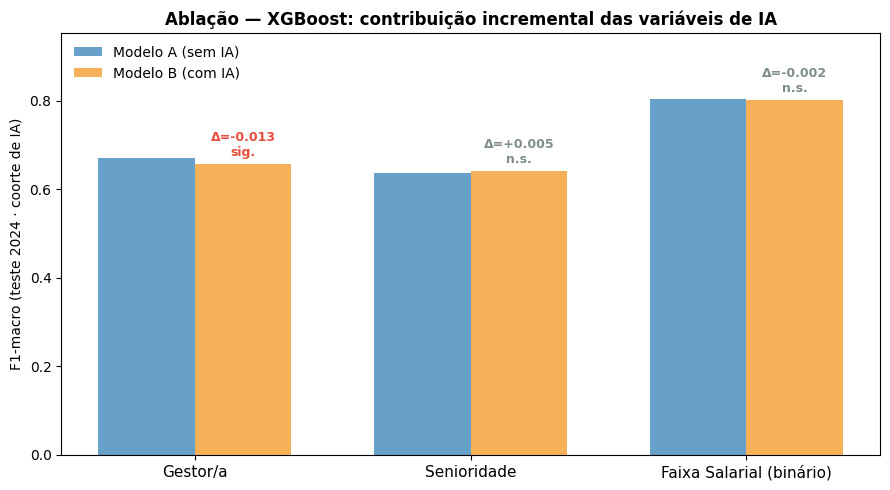

figures/ablacao_ia.png


In [43]:
def _f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)


def _gap_f1_genero(y_true, y_pred, genero):
    """Gap = F1-macro(Masculino) − F1-macro(Feminino)."""
    g  = np.asarray(genero)
    f1 = {}
    for k in ['Masculino', 'Feminino']:
        m = (g == k)
        f1[k] = _f1_macro(y_true[m], y_pred[m]) if m.sum() > 0 else np.nan
    return f1['Masculino'] - f1['Feminino']


def tabela_ablacao(results_A: dict, results_B: dict,
                   targets: list = TARGETS_CENTRAIS,
                   n_boot: int = 1000, seed: int = SEED) -> pd.DataFrame:
    """
    ΔF1 = F1_B − F1_A por desfecho, com IC 95% (bootstrap pareado) e ΔGap M−F.
    A e B compartilham EXATAMENTE o mesmo teste (prepare_xy filtra linhas por
    NaN no target, que independe das features), então o bootstrap reamostra os
    mesmos índices para os dois modelos — isolando o efeito das variáveis de IA.
    """
    rng  = np.random.RandomState(seed)
    rows = []
    for target in targets:
        ra, rb = results_A[target], results_B[target]
        yA, pA = ra['y_te'].values, np.asarray(ra['y_pred'])
        yB, pB = rb['y_te'].values, np.asarray(rb['y_pred'])
        gen    = ra['meta']['genero'].values

        f1_a, f1_b = _f1_macro(yA, pA), _f1_macro(yB, pB)
        delta      = f1_b - f1_a

        n     = len(yA)
        boots = np.empty(n_boot)
        for b in range(n_boot):
            idx      = rng.randint(0, n, n)
            boots[b] = _f1_macro(yB[idx], pB[idx]) - _f1_macro(yA[idx], pA[idx])
        lo, hi = np.percentile(boots, [2.5, 97.5])

        d_gap = _gap_f1_genero(yB, pB, gen) - _gap_f1_genero(yA, pA, gen)

        rows.append({
            'Desfecho':    TARGET_LABELS[target],
            'F1-macro A':  round(f1_a, 4),
            'F1-macro B':  round(f1_b, 4),
            'ΔF1 (B−A)':   round(delta, 4),
            'IC 95% ΔF1':  f'[{lo:+.4f}, {hi:+.4f}]',
            'Signif.':     'sig.' if (lo > 0 or hi < 0) else 'n.s.',
            'ΔGap M−F':    round(d_gap, 4),
        })
    return pd.DataFrame(rows).set_index('Desfecho')


tab_ablacao = tabela_ablacao(results_A_ia, results_B_ia)
print('\n=== ABLAÇÃO (coorte de IA 2023→2024): ganho incremental das variáveis de IA ===')
print(tab_ablacao.to_string())
print('\nLeitura:')
print('  • ΔF1>0 com IC 95% que NÃO cruza zero → a IA agrega de forma robusta.')
print('  • ΔGap M−F < 0 → acrescentar IA REDUZ o gap de desempenho entre gêneros.')


def plot_ablacao(tab: pd.DataFrame, fname: str = 'ablacao_ia.png'):
    labels = tab.index.tolist()
    x, w   = np.arange(len(labels)), 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - w/2, tab['F1-macro A'], w, label='Modelo A (sem IA)',  color='#4C8FBF', alpha=0.85)
    ax.bar(x + w/2, tab['F1-macro B'], w, label='Modelo B (com IA)', color='#F4A43B', alpha=0.85)

    for xi, (_, row) in enumerate(tab.iterrows()):
        delta = row['ΔF1 (B−A)']
        cor   = '#2ECC71' if delta > 0.005 else ('#E74C3C' if delta < -0.005 else '#7F8C8D')
        ax.annotate(f"Δ={delta:+.3f}\n{row['Signif.']}", xy=(xi + w/2, row['F1-macro B']),
                    xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=9, color=cor, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('F1-macro (teste 2024 · coorte de IA)')
    ax.set_ylim(0, min(1.0, tab[['F1-macro A', 'F1-macro B']].max().max() + 0.15))
    ax.set_title(f'Ablação — {ESTIMADOR_CENTRAL}: contribuição incremental das variáveis de IA',
                 fontweight='bold', fontsize=12)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'figures/{fname}')


plot_ablacao(tab_ablacao)


## 4.6 Equidade consolidada (A e B, todos os targets centrais)

In [44]:
for col in IA_FEATURES_MODELO_B:
    print(col)
    print(pd.crosstab(df[col].isna(), df['gestor'], normalize='index'))
    print()

ia_nao_usa
gestor           0.0       1.0
ia_nao_usa                    
False       1.000000  0.000000
True        0.618177  0.381823

ia_usa_gratuita
gestor                0.0       1.0
ia_usa_gratuita                    
False            1.000000  0.000000
True             0.618177  0.381823

ia_usa_paga_prop
gestor                 0.0       1.0
ia_usa_paga_prop                    
False             1.000000  0.000000
True              0.618177  0.381823

ia_usa_paga_emp
gestor                0.0       1.0
ia_usa_paga_emp                    
False            1.000000  0.000000
True             0.618177  0.381823

ia_usa_copilot
gestor               0.0       1.0
ia_usa_copilot                    
False           1.000000  0.000000
True            0.618177  0.381823

ia_empresa_prioridade_alta
gestor                           0.0       1.0
ia_empresa_prioridade_alta                    
False                       0.000000  1.000000
True                        0.911106  0.088894

ia_o

In [45]:
frames = []
for target in TARGETS_CENTRAIS:
    for key, results in [('A', results_A), ('B', results_B)]:
        df_eq = results[target]['df_equidade'].copy()
        df_eq.insert(0, 'Modelo',    key)
        df_eq.insert(0, 'Desfecho',  TARGET_LABELS[target])
        frames.append(df_eq)

df_eq_all = pd.concat(frames, ignore_index=True)
print('\n=== AVALIAÇÃO DE EQUIDADE CONSOLIDADA ===')
print(df_eq_all.to_string(index=False))
df_eq_all.to_excel('equidade_consolidada.xlsx', index=False)


=== AVALIAÇÃO DE EQUIDADE CONSOLIDADA ===
                Desfecho Modelo    Gênero      N  F1-macro  Precision-mac  Recall-mac    FNR
                Gestor/a      A Masculino 3678.0    0.6746         0.6647      0.6954 0.4024
                Gestor/a      A  Feminino 1137.0    0.6369         0.6256      0.6685 0.4619
                Gestor/a      B Masculino 3678.0    0.6710         0.6632      0.6833 0.4467
                Gestor/a      B  Feminino 1137.0    0.6488         0.6364      0.6780 0.4569
             Senioridade      A Masculino 2843.0    0.6498         0.6468      0.6539    NaN
             Senioridade      A  Feminino  940.0    0.6265         0.6266      0.6270    NaN
             Senioridade      B Masculino 2843.0    0.6477         0.6477      0.6478    NaN
             Senioridade      B  Feminino  940.0    0.6419         0.6473      0.6400    NaN
Faixa Salarial (binário)      A Masculino 3652.0    0.7999         0.7990      0.8009 0.2252
Faixa Salarial (binário)   

## 4.7 Experimento de sensibilidade: granularidade do target salarial


In [46]:
print('\n=== Sensibilidade: Granularidade do Target Salarial ===')
targets_sal = ['faixa_salarial_bin', 'faixa_salarial_3', 'faixa_salarial']
rows_sal    = []

for t in targets_sal:
    r  = treinar_avaliar(t, TARGETS[t], df_train, df_test, modelo_key='B', run_cv_interno=False)
    f1 = f1_score(r['y_te'], r['y_pred'], average='macro', zero_division=0)
    rows_sal.append({
        'Versão':      TARGET_LABELS[t],
        'Nº classes':  len(set(r['y_te'])),
        'F1-macro':    round(f1, 4),
    })

print(pd.DataFrame(rows_sal).to_string(index=False))


=== Sensibilidade: Granularidade do Target Salarial ===

  Faixa Salarial (binário) [Modelo B]
  Treino: 10,643 | Teste: 4,784 | Classes: [np.int64(0), np.int64(1)]

  ── Estimador central: XGBoost ──


              precision    recall  f1-score   support

           0       0.87      0.83      0.85      2961
           1       0.74      0.79      0.77      1823

    accuracy                           0.82      4784
   macro avg       0.80      0.81      0.81      4784
weighted avg       0.82      0.82      0.82      4784


  ── Métricas de Equidade ──
  Equal Opportunity Difference (TPR_Masc − TPR_Fem): -0.0338
  Demographic Parity Difference:                      +0.0755
  Gap F1 (Masc − Fem): -0.0016  → equilibrado
   Gênero      N  F1-macro  Precision-mac  Recall-mac    FNR
Masculino 3652.0    0.8055         0.8043      0.8071 0.2139
 Feminino 1132.0    0.8071         0.7948      0.8291 0.1801

  Faixa Salarial (3 classes) [Modelo B]
  Treino: 10,643 | Teste: 4,784 | Classes: [np.int64(0), np.int64(1), np.int64(2)]

  ── Estimador central: XGBoost ──
              precision    recall  f1-score   support

           0       0.69      0.73      0.71      1244
           1       0.5

---
## Seção 5 — Explicabilidade com SHAP

## 5.0 Utilitários

In [47]:
_CAT_PREFIX = ('cat__', 'num__')

def _strip_prefix(raw: str) -> str:
    for p in _CAT_PREFIX:
        if raw.startswith(p):
            return raw[len(p):]
    return raw

def parse_feature(raw: str):
    """
    Decompõe um nome cru do get_feature_names_out em:
      base   -> variável original ('ia_nao_usa', 'modalidade', ...)
      label  -> rótulo legível (usa IA_FEATURE_LABELS quando for IA)
      is_ia  -> True se for feature de IA generativa
      is_np  -> True se a categoria for 'Não perguntado' (artefato temporal)
    """
    name = _strip_prefix(raw)
    is_ia = any(name.startswith(f) for f in IA_FEATURES)
    is_np = NAO_PERGUNTADO in name
    # base = variável original: para IA, casa com o prefixo conhecido
    base = name
    if is_ia:
        base = next(f for f in IA_FEATURES if name.startswith(f))
        label = IA_FEATURE_LABELS.get(base, base)
    else:
        # estrutural OHE 'col_categoria' -> mostra 'col: categoria' de forma curta
        label = name.replace('_', ' ')
        if len(label) > 34:
            label = label[:34] + '…'
    return base, label, is_ia, is_np


def build_feature_group_map(pre):
    """Mapeia cada coluna transformada de volta à VARIÁVEL ORIGINAL (base)."""
    mapping = []
    for name, trans, cols in pre.transformers_:
        if name == 'remainder':
            continue
        if name == 'num':
            mapping.extend(cols)
        elif name == 'cat':
            ohe = trans.named_steps['ohe']
            for col, cats in zip(cols, ohe.categories_):
                mapping.extend([col] * len(cats))
    return mapping


def pretty_label(base: str) -> str:
    """Rótulo legível de uma variável ORIGINAL (base) p/ os gráficos agregados."""
    if base in IA_FEATURE_LABELS:
        return IA_FEATURE_LABELS[base]
    return base.replace('_', ' ')


def is_ia_base(base: str) -> bool:
    return base in IA_FEATURES


In [48]:
def compute_shap(pipe, X, max_samples: int = 200, return_diag: bool = False):
  
    pre = pipe.named_steps['pre']
    clf = pipe.named_steps['clf']

    idx = np.random.RandomState(SEED).choice(len(X), min(max_samples, len(X)), replace=False)
    X_t = pre.transform(X.iloc[idx])

    sv = shap.TreeExplainer(
        clf, feature_perturbation='tree_path_dependent'
    ).shap_values(X_t, check_additivity=False)

    if isinstance(sv, list):                       # API antiga: lista por classe
        mean_abs_raw = np.mean([np.abs(s) for s in sv], axis=0).mean(axis=0)
    else:
        sv = np.array(sv)
        if sv.ndim == 3:
            n_classes = sv.shape[-1]
            if n_classes == 2:                     # binário -> classe positiva
                mean_abs_raw = np.abs(sv[:, :, 1]).mean(axis=0)
            else:                                  # multiclasse -> média amostras+classes
                mean_abs_raw = np.abs(sv).mean(axis=(0, 2))
        else:
            mean_abs_raw = np.abs(sv).mean(axis=0)

    raw_names = list(pre.get_feature_names_out())

    # --- diagnóstico do artefato temporal (antes de agregar) ---
    total_raw = mean_abs_raw.sum()
    np_share = (sum(v for v, rn in zip(mean_abs_raw, raw_names) if NAO_PERGUNTADO in rn)
                / total_raw) if total_raw > 0 else 0.0

    # --- agregação por variável original ---
    group_map = build_feature_group_map(pre)
    s_agg = pd.Series(mean_abs_raw, index=group_map).groupby(level=0).sum()
    s_agg = s_agg.sort_values(ascending=False)

    mean_abs = s_agg.values
    bases    = s_agg.index.to_numpy()

    total = mean_abs.sum()
    if total > 0:
        mean_abs = mean_abs / total

    if return_diag:
        return mean_abs, bases, {'nao_perguntado_share': np_share}
    return mean_abs, bases


In [49]:
def plot_shap_bar(mean_shap, bases, top_n: int = 15,
                  title: str = 'SHAP', fname: str = 'shap.png',
                  highlight_ia: bool = True, ax=None):
    top = np.argsort(mean_shap)[::-1][:top_n]
    names  = [pretty_label(bases[i]) for i in top]
    vals   = mean_shap[top]
    colors = (['#F4A43B' if is_ia_base(bases[i]) else '#4C8FBF' for i in top]
              if highlight_ia else ['#4C8FBF'] * len(top))

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(names[::-1], vals[::-1], color=colors[::-1])
    ax.set_xlabel('Mean |SHAP| (normalizado, agregado por variável)')
    ax.set_title(title, fontweight='bold', loc='left')
    if own_fig:
        if highlight_ia:
            ax.legend(handles=[
                mpatches.Patch(color='#F4A43B', label='Variável de IA generativa'),
                mpatches.Patch(color='#4C8FBF', label='Variável estrutural'),
            ], loc='lower right', frameon=False)
        fig.subplots_adjust(left=0.32)
        plt.savefig(f'figures/{fname}', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'  figures/{fname}')


## 5.1 SHAP global

  Gestor/a                     | share "Não perguntado" (B): 0.0%
  Senioridade                  | share "Não perguntado" (B): 0.0%
  Faixa Salarial (binário)     | share "Não perguntado" (B): 0.0%


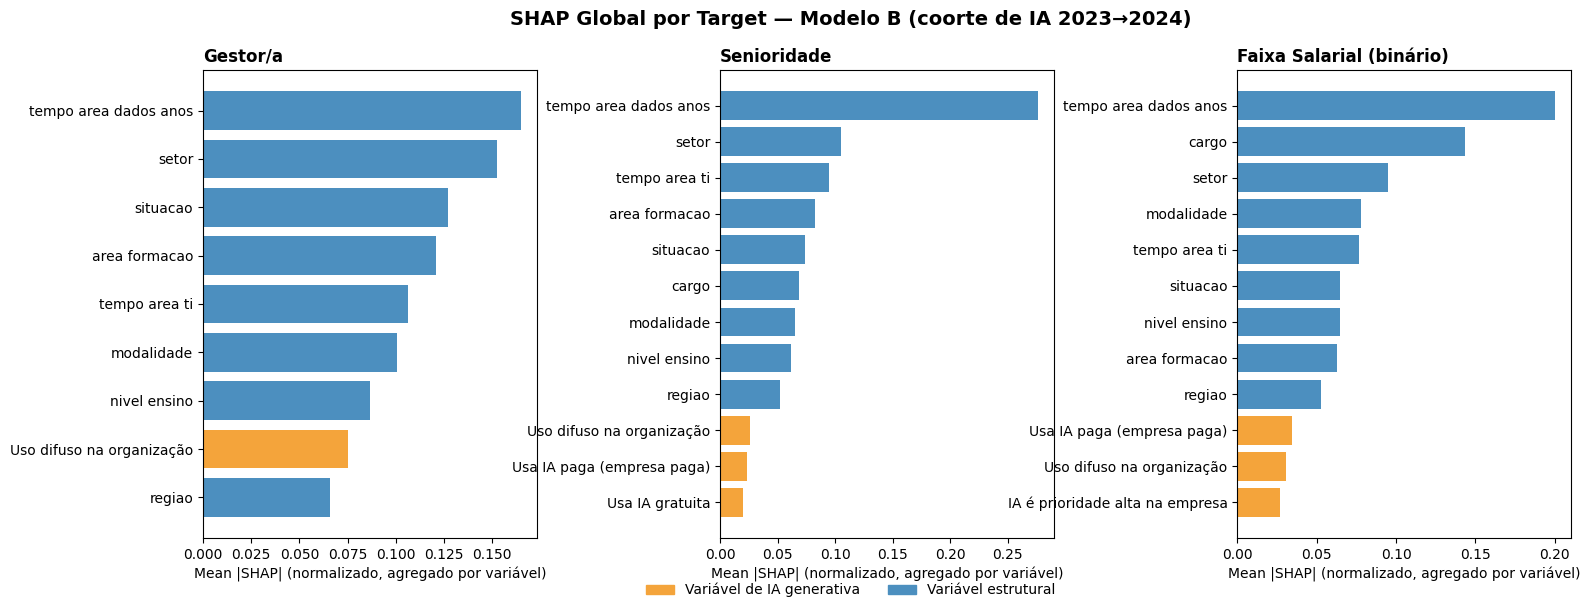

  figures/shap_global_targets_B.png


In [50]:
shap_cache = {}   # guarda (mean_abs, bases) por 'A_target' / 'B_target'

fig, axes = plt.subplots(1, len(TARGETS_CENTRAIS), figsize=(6*len(TARGETS_CENTRAIS), 6))
if len(TARGETS_CENTRAIS) == 1:
    axes = [axes]

for ax, target in zip(axes, TARGETS_CENTRAIS):
    for key, res in [('A', results_A_ia), ('B', results_B_ia)]:
        r = res[target]
        ms, bs, diag = compute_shap(r['pipe'], r['X_te'], return_diag=True)
        shap_cache[f'{key}_{target}'] = (ms, bs)
        if key == 'B':
            print(f'  {TARGET_LABELS[target]:28s} | share "Não perguntado" (B): '
                  f'{diag["nao_perguntado_share"]*100:.1f}%')

    ms_b, bs_b = shap_cache[f'B_{target}']
    plot_shap_bar(ms_b, bs_b, top_n=12,
                  title=f'{TARGET_LABELS[target]}', ax=ax)

fig.suptitle('SHAP Global por Target — Modelo B (coorte de IA 2023→2024)',
             fontsize=14, fontweight='bold')
fig.legend(handles=[
    mpatches.Patch(color='#F4A43B', label='Variável de IA generativa'),
    mpatches.Patch(color='#4C8FBF', label='Variável estrutural'),
], loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(left=0.14, wspace=0.55, bottom=0.10)
plt.savefig('figures/shap_global_targets_B.png', dpi=150, bbox_inches='tight')
plt.show()
print('  figures/shap_global_targets_B.png')


## 5.2 SHAP por gênero 

In [51]:
def compute_shap_genero(pipe, X_te, meta, max_samples: int = 200) -> dict:
    """SHAP agregado por variável, separado por gênero. {genero: (mean_abs, bases)}."""
    out = {}
    for g in ['Masculino', 'Feminino']:
        mask = (meta['genero'] == g).values
        X_sub = X_te[mask]
        if len(X_sub) < 20:
            print(f'  Aviso: n={len(X_sub)} para {g} — SHAP ignorado')
            continue
        out[g] = compute_shap(pipe, X_sub, max_samples=max_samples)
    return out


def spearman_rankings(ms_m, bs_m, ms_f, bs_f, top_n: int = 15):
    """Spearman entre rankings de importância por gênero (interseção do top-N).
       NOTA: mede concordância apenas nas variáveis comuns aos dois tops."""
    def top_feats(ms, bs, n):
        n = min(n, len(ms))  
        idx = np.argsort(ms)[::-1][:n]
        return [pretty_label(bs[i]) for i in idx], np.sort(ms)[::-1][:n]
    feats_m, vals_m = top_feats(ms_m, bs_m, top_n)
    feats_f, vals_f = top_feats(ms_f, bs_f, top_n)
    comum = [f for f in feats_m if f in feats_f]
    if len(comum) < 5:
        print(f'  Menos de 5 variáveis comuns ({len(comum)}) — Spearman não calculado')
        return None
    rho, p = spearmanr([feats_m.index(f)+1 for f in comum],
                       [feats_f.index(f)+1 for f in comum])
    nivel = ('Alta' if rho > 0.7 else 'Moderada' if rho > 0.4 else 'Baixa')
    print(f'  ρ Spearman (n={len(comum)} comuns): {rho:.3f}  p={p:.4f} → concordância {nivel}')
    df_m = pd.DataFrame({'Rank': range(1, len(feats_m)+1), 'Var_Masc': feats_m, 'SHAP_Masc': np.round(vals_m,4)})
    df_f = pd.DataFrame({'Rank': range(1, len(feats_f)+1), 'Var_Fem':  feats_f, 'SHAP_Fem':  np.round(vals_f,4)})
    return df_m.merge(df_f, on='Rank')


def plot_shap_genero(shap_g: dict, target: str, top_n: int = 12):
    if 'Masculino' not in shap_g or 'Feminino' not in shap_g:
        print(f'  Dados insuficientes — {target}'); return
    ms_m, bs_m = shap_g['Masculino']; ms_f, bs_f = shap_g['Feminino']
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, (ms, bs), tit, cbase in zip(
            axes, [(ms_m, bs_m), (ms_f, bs_f)], ['Masculino', 'Feminino'],
            ['#517493', '#64313E']):
        idx = np.argsort(ms)[::-1][:top_n]
        names = [pretty_label(bs[i]) for i in idx]
        vals  = ms[idx]
        colors = ['#F4A43B' if is_ia_base(bs[i]) else cbase for i in idx]
        ax.barh(names[::-1], vals[::-1], color=colors[::-1], alpha=0.9)
        ax.set_xlabel('Mean |SHAP| (normalizado por painel)')
        ax.set_title(tit, fontweight='bold', fontsize=12)
    fig.suptitle(f'SHAP por Gênero — {TARGET_LABELS[target]} (Modelo B)',
                 fontsize=13, fontweight='bold')
    fig.legend(handles=[
        mpatches.Patch(color='#F4A43B', label='Variável de IA generativa'),
        mpatches.Patch(color='#517493', label='Estrutural (Masc.)'),
        mpatches.Patch(color='#64313E', label='Estrutural (Fem.)'),
    ], loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
    fig.subplots_adjust(left=0.22, wspace=0.55, bottom=0.12)
    plt.savefig(f'figures/shap_genero_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  figures/shap_genero_{target}.png')



  SHAP por Gênero — Gestor/a
  ρ Spearman (n=9 comuns): 0.967  p=0.0000 → concordância Alta
 Rank                  Var_Masc  SHAP_Masc                   Var_Fem  SHAP_Fem
    1     tempo area dados anos     0.1762     tempo area dados anos    0.1732
    2                     setor     0.1547                     setor    0.1461
    3                  situacao     0.1210                  situacao    0.1354
    4             area formacao     0.1117             area formacao    0.1324
    5             tempo area ti     0.1056                modalidade    0.1015
    6                modalidade     0.1020             tempo area ti    0.0993
    7              nivel ensino     0.0868              nivel ensino    0.0803
    8 Uso difuso na organização     0.0755                    regiao    0.0696
    9                    regiao     0.0665 Uso difuso na organização    0.0620


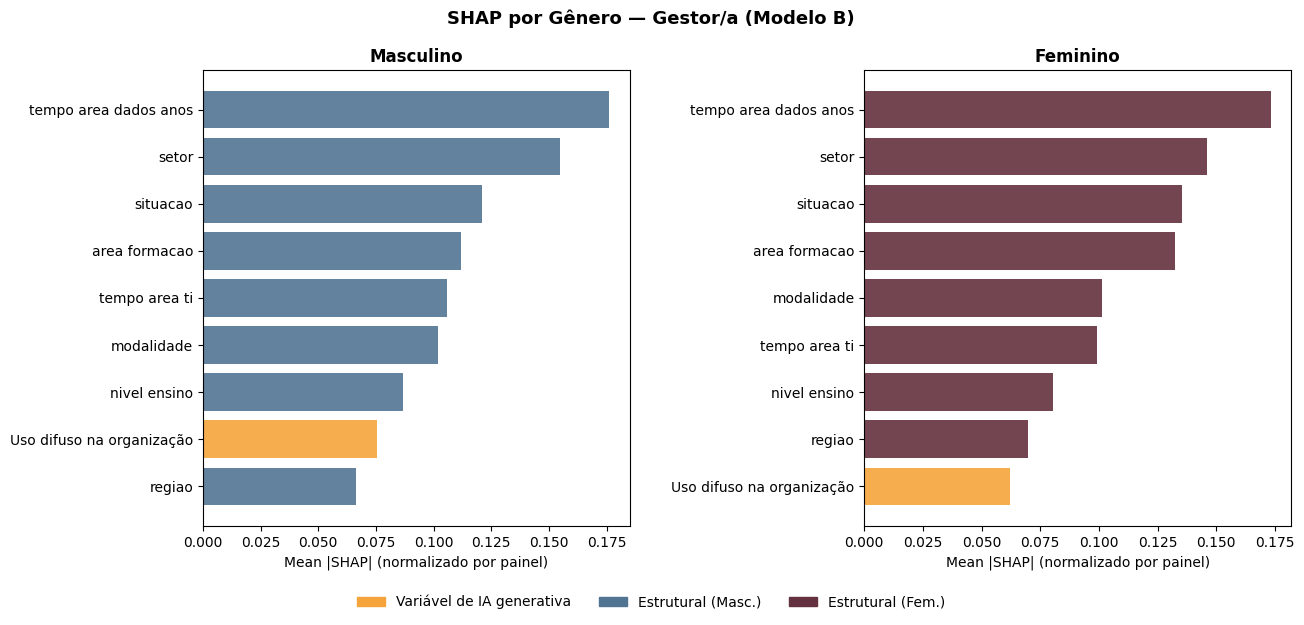

  figures/shap_genero_gestor.png

  SHAP por Gênero — Senioridade
  ρ Spearman (n=15 comuns): 0.975  p=0.0000 → concordância Alta
 Rank                    Var_Masc  SHAP_Masc                     Var_Fem  SHAP_Fem
    1       tempo area dados anos     0.2856       tempo area dados anos    0.2825
    2                       setor     0.1124                       setor    0.1045
    3               tempo area ti     0.0901               area formacao    0.0936
    4               area formacao     0.0838               tempo area ti    0.0782
    5                       cargo     0.0716                    situacao    0.0772
    6                  modalidade     0.0679                       cargo    0.0709
    7                    situacao     0.0599                nivel ensino    0.0654
    8                nivel ensino     0.0593                  modalidade    0.0597
    9                      regiao     0.0506                      regiao    0.0495
   10   Uso difuso na organização     0.

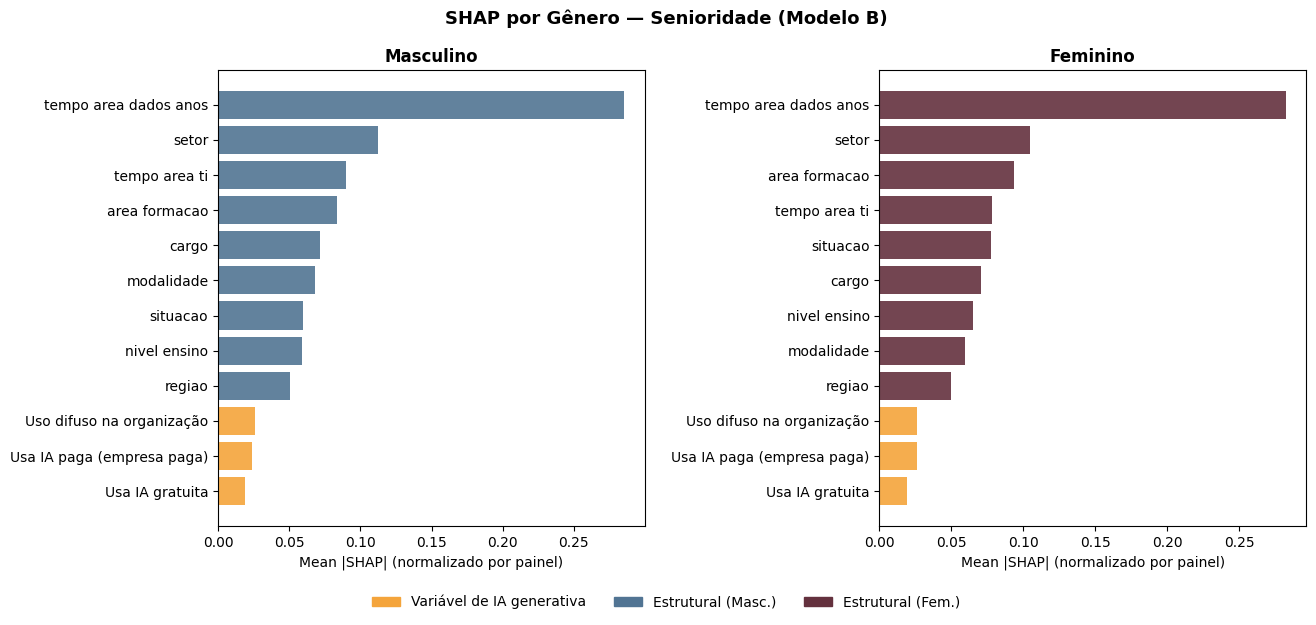

  figures/shap_genero_nivel.png

  SHAP por Gênero — Faixa Salarial (binário)
  ρ Spearman (n=15 comuns): 0.986  p=0.0000 → concordância Alta
 Rank                        Var_Masc  SHAP_Masc                         Var_Fem  SHAP_Fem
    1           tempo area dados anos     0.1764           tempo area dados anos    0.1983
    2                           cargo     0.1437                           cargo    0.1467
    3                           setor     0.0949                           setor    0.0906
    4                      modalidade     0.0853                      modalidade    0.0754
    5                   tempo area ti     0.0813                        situacao    0.0705
    6                        situacao     0.0701                   tempo area ti    0.0698
    7                    nivel ensino     0.0650                   area formacao    0.0697
    8                   area formacao     0.0547                    nivel ensino    0.0634
    9                          regiao  

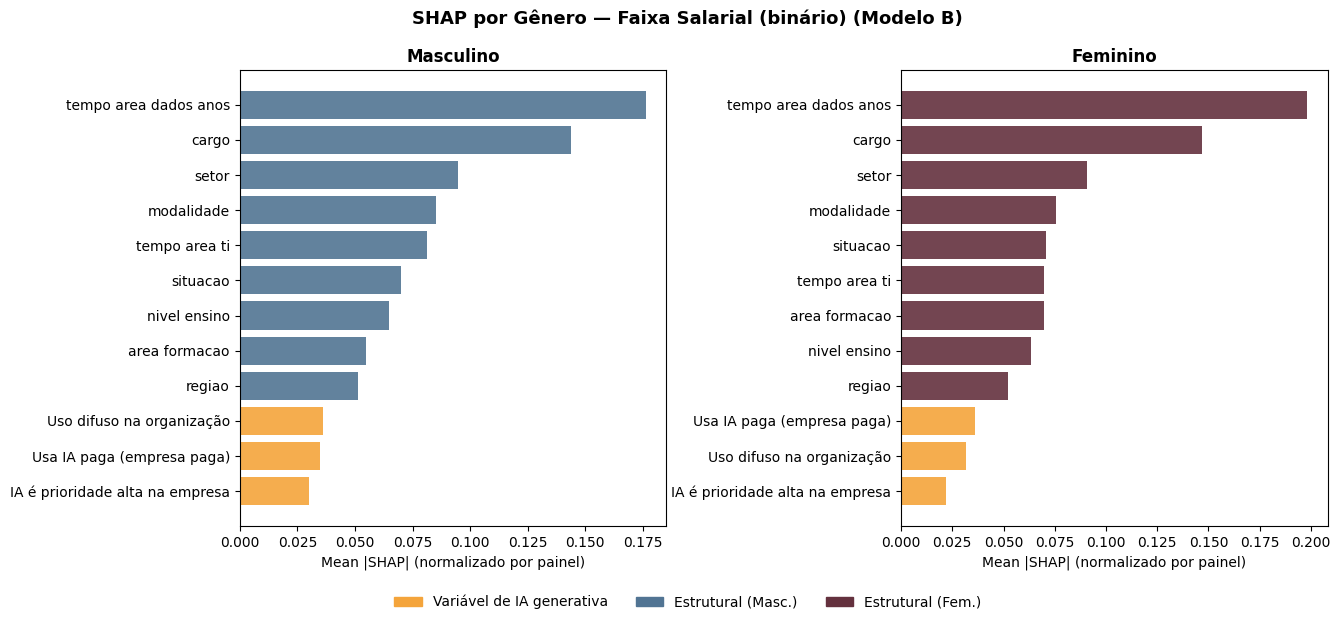

  figures/shap_genero_faixa_salarial_bin.png


In [52]:
for target in TARGETS_CENTRAIS:
    print(f'\n{"="*55}\n  SHAP por Gênero — {TARGET_LABELS[target]}\n{"="*55}')
    rb = results_B_ia[target]
    shap_g = compute_shap_genero(rb['pipe'], rb['X_te'], rb['meta'])
    if 'Masculino' in shap_g and 'Feminino' in shap_g:
        comp = spearman_rankings(*shap_g['Masculino'], *shap_g['Feminino'])
        if comp is not None:
            print(comp.to_string(index=False))
        plot_shap_genero(shap_g, target)

### 5.3 — Modelo A vs. B

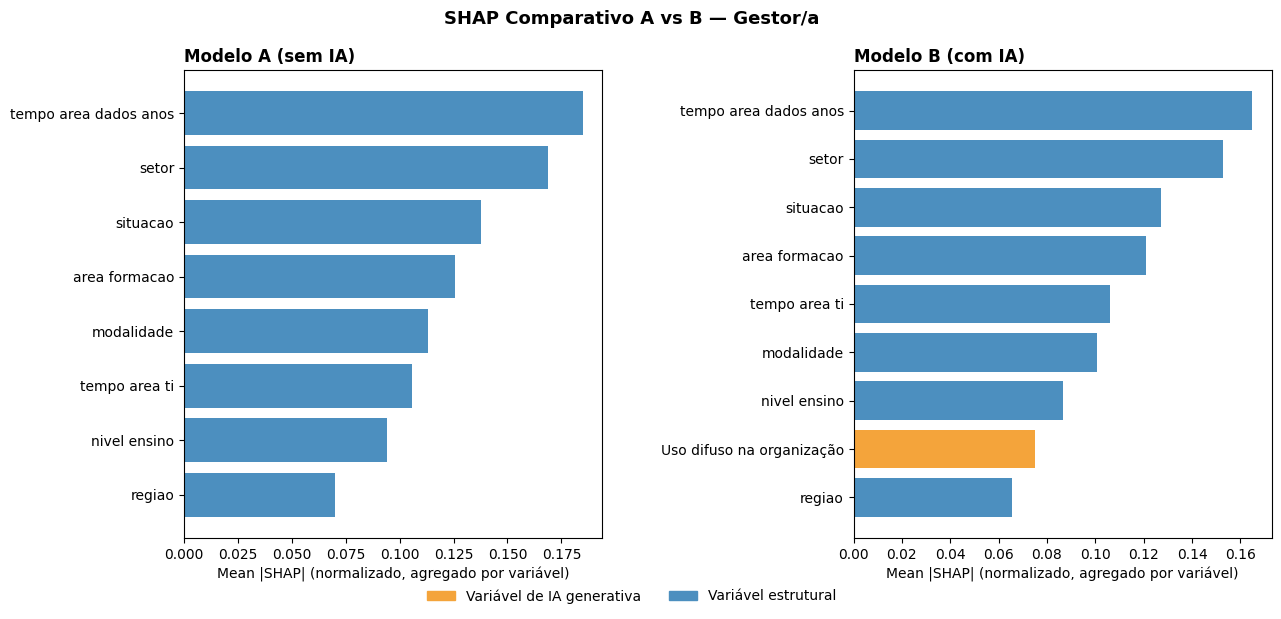

  figures/shap_comp_gestor.png


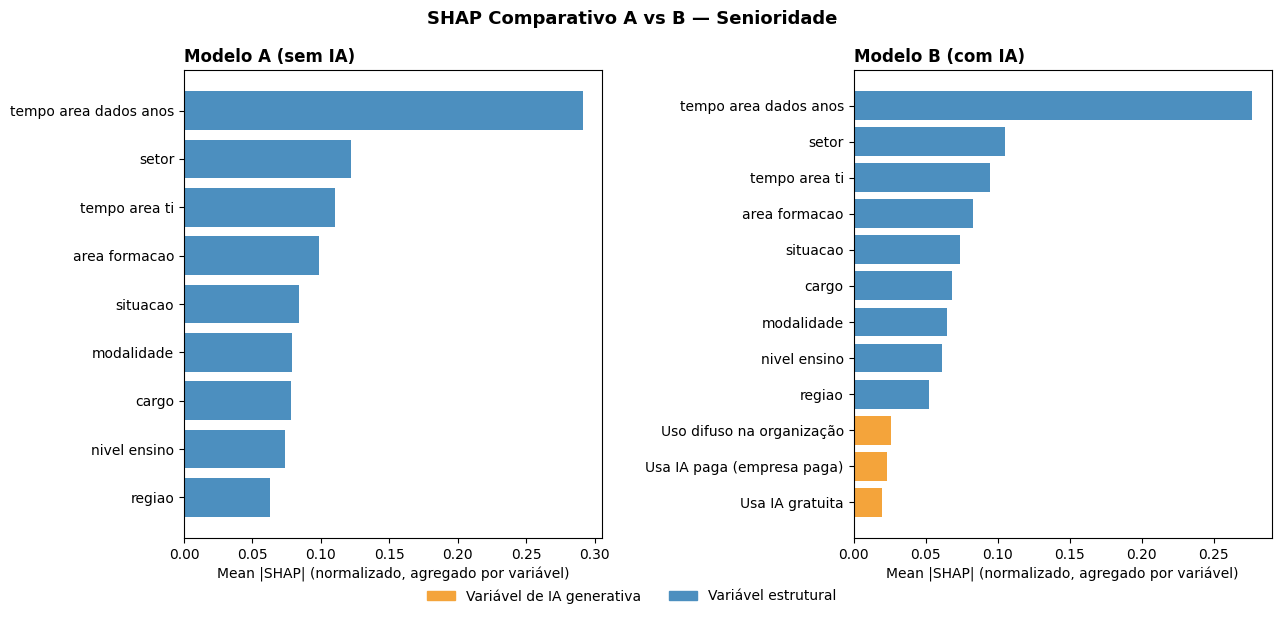

  figures/shap_comp_nivel.png


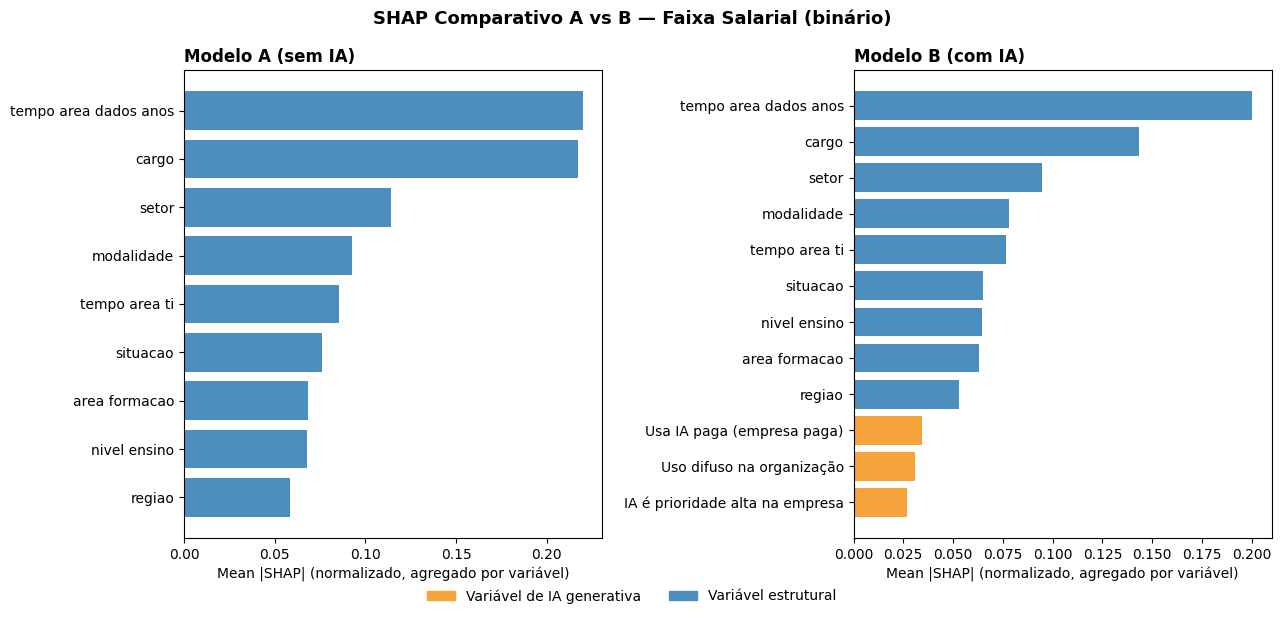

  figures/shap_comp_faixa_salarial_bin.png


In [53]:
for target in TARGETS_CENTRAIS:
    safe = target.replace(' ', '_')
    ms_a, bs_a = shap_cache[f'A_{target}']
    ms_b, bs_b = shap_cache[f'B_{target}']
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_shap_bar(ms_a, bs_a, top_n=12, title='Modelo A (sem IA)',
                  highlight_ia=False, ax=axes[0])
    plot_shap_bar(ms_b, bs_b, top_n=12, title='Modelo B (com IA)',
                  highlight_ia=True, ax=axes[1])
    fig.suptitle(f'SHAP Comparativo A vs B — {TARGET_LABELS[target]}',
                 fontsize=13, fontweight='bold')
    fig.legend(handles=[
        mpatches.Patch(color='#F4A43B', label='Variável de IA generativa'),
        mpatches.Patch(color='#4C8FBF', label='Variável estrutural'),
    ], loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.03))
    fig.subplots_adjust(left=0.22, wspace=0.6, bottom=0.10)
    plt.savefig(f'figures/shap_comp_{safe}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  figures/shap_comp_{safe}.png')

### 5.4 — Beeswarm

In [55]:
def _raw_shap(pipe, X, max_samples: int = 200):
    """
    Retorna os valores SHAP por amostra (não agregados), a matriz transformada
    correspondente e os nomes brutos das colunas — usado pelo beeswarm, que
    precisa do detalhe por observação (compute_shap() só devolve a média |SHAP|,
    célula 5.0). Mesma lógica de seleção de classe positiva / achatamento
    multiclasse de compute_shap(), pra manter os dois caminhos consistentes.
    """
    pre = pipe.named_steps['pre']
    clf = pipe.named_steps['clf']

    idx = np.random.RandomState(SEED).choice(len(X), min(max_samples, len(X)), replace=False)
    X_t = pre.transform(X.iloc[idx])

    sv = shap.TreeExplainer(
        clf, feature_perturbation='tree_path_dependent'
    ).shap_values(X_t, check_additivity=False)

    if isinstance(sv, list):                     # API antiga: lista por classe
        sv = sv[1] if len(sv) == 2 else np.mean(sv, axis=0)
    else:
        sv = np.array(sv)
        if sv.ndim == 3:                          # (n, features, classes)
            sv = sv[:, :, 1] if sv.shape[-1] == 2 else sv.mean(axis=2)

    raw_names = list(pre.get_feature_names_out())
    return sv, X_t, np.array(raw_names)

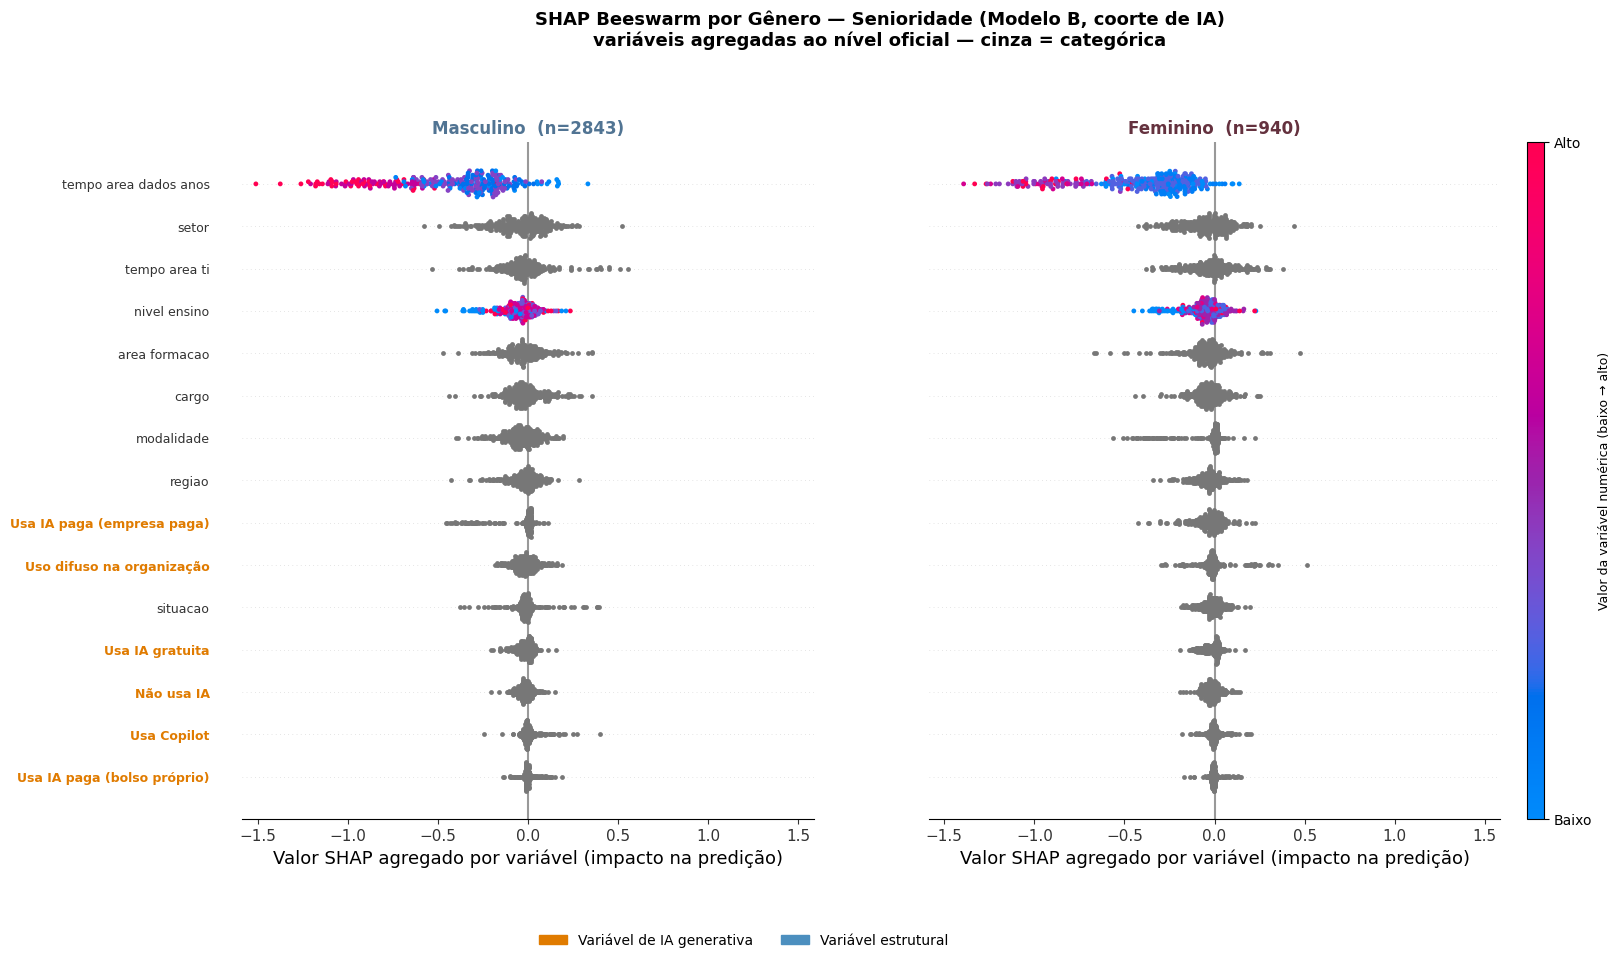

  figures/shap_beeswarm_genero_nivel_B.png


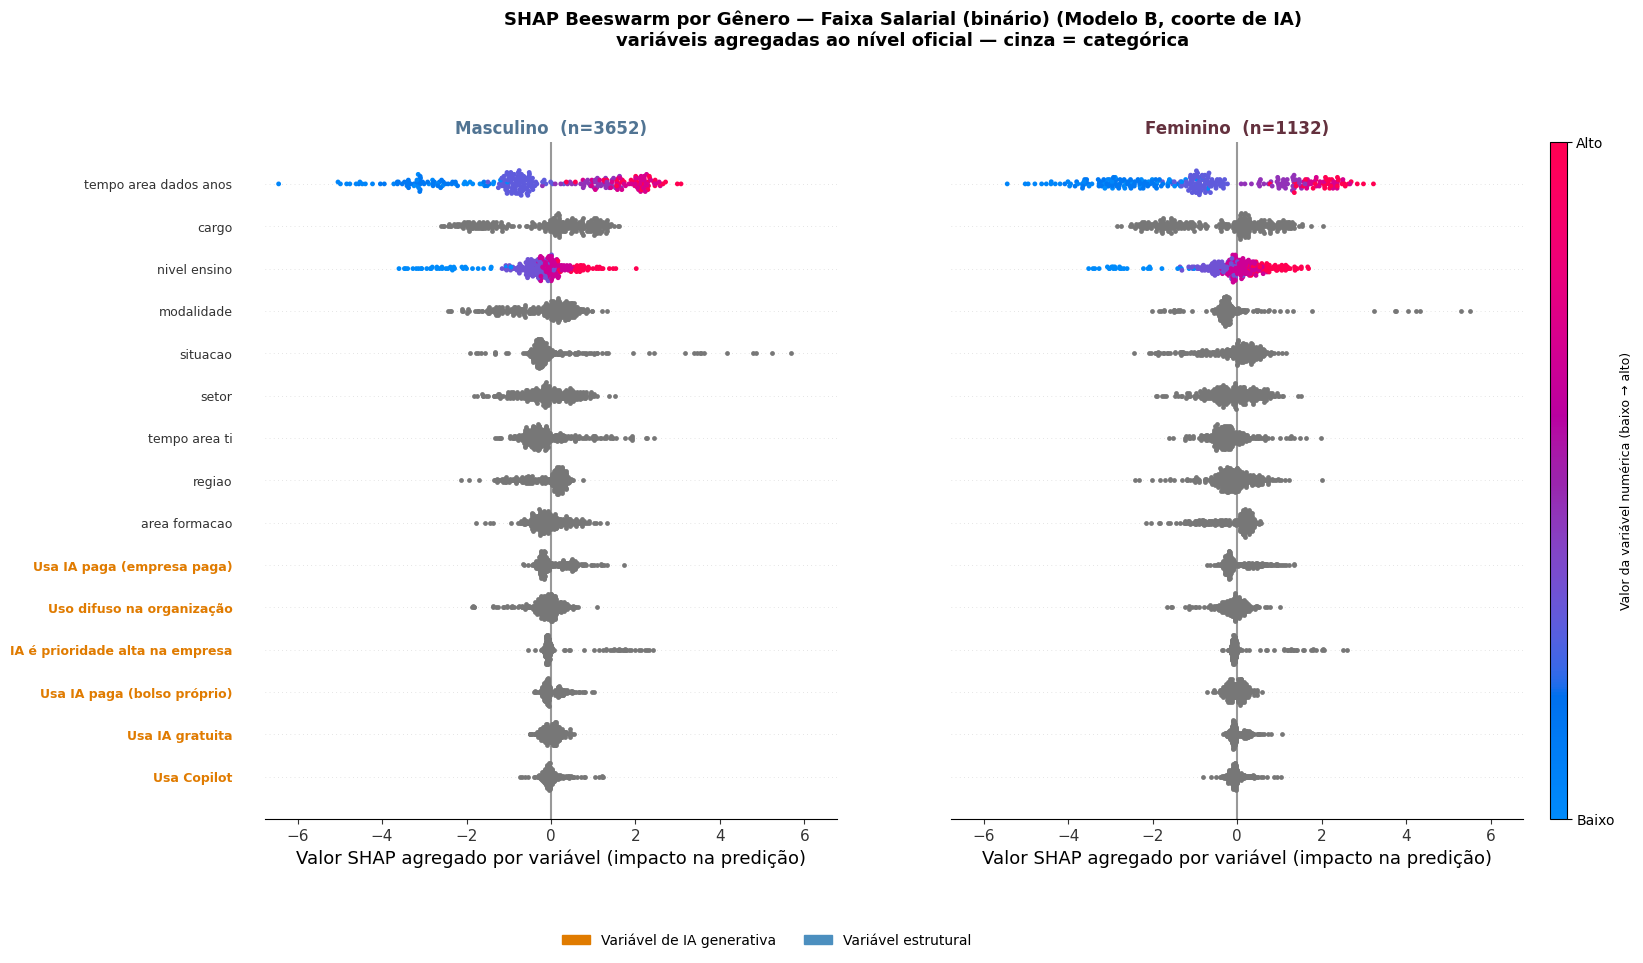

  figures/shap_beeswarm_genero_faixa_salarial_bin_B.png


In [56]:
def build_var_groups(pre):
    """Retorna (num_bases, cat_bases) — nomes das variáveis originais por tipo."""
    num_bases, cat_bases = set(), set()
    for name, trans, cols in pre.transformers_:
        if name == 'num':
            num_bases.update(cols)
        elif name == 'cat':
            cat_bases.update(cols)
    return num_bases, cat_bases


def aggregate_shap_by_base(sv, Xt, raw_names, pre):
    """
    Soma o SHAP das colunas one-hot que pertencem à mesma variável original
    (válido pela aditividade do SHAP). Numéricas mantêm o valor real
    (para colorir); categóricas recebem NaN no 'data' — não há um único
    valor alto/baixo que represente 'ser desta categoria', então o ponto
    aparece sem cor no beeswarm.
    """
    full_raw   = list(pre.get_feature_names_out())
    full_group = build_feature_group_map(pre)          # já existe (célula 79)
    pos        = {name: i for i, name in enumerate(full_raw)}
    group_of   = np.array([full_group[pos[rn]] for rn in raw_names])

    num_bases, _ = build_var_groups(pre)

    df_sv  = pd.DataFrame(sv, columns=group_of)
    sv_agg = df_sv.T.groupby(level=0).sum().T           # soma por variável base
    bases  = sv_agg.columns.to_numpy()

    data_agg = np.full((sv.shape[0], len(bases)), np.nan)
    for j, base in enumerate(bases):
        if base in num_bases:
            col_idx = np.where(group_of == base)[0][0]  # numérica = 1 coluna só
            data_agg[:, j] = Xt[:, col_idx]

    return sv_agg.values, data_agg, bases


def plot_beeswarm_genero(pipe, X_te, meta, target='nivel', top_n=15, max_samples=300):
    pre = pipe.named_steps['pre']

    # 1) SHAP agregado por variável original, amostra combinada -> define o ranking
    sv_all, Xt_all, raw = _raw_shap(pipe, X_te, max_samples=max_samples)
    keep = np.array([NAO_PERGUNTADO not in r for r in raw])
    if (~keep).any():
        print(f'  Aviso: {int((~keep).sum())} dummies "Não perguntado" removidas '
              f'(artefato temporal — use a coorte de IA para eliminá-las na raiz).')
    sv_all, Xt_all, raw = sv_all[:, keep], Xt_all[:, keep], raw[keep]

    sv_agg_all, _, bases = aggregate_shap_by_base(sv_all, Xt_all, raw, pre)
    mean_abs = np.abs(sv_agg_all).mean(0)
    top_idx  = np.argsort(mean_abs)[::-1][:top_n]
    top_bases  = bases[top_idx]
    top_labels = [pretty_label(b) for b in top_bases]
    top_is_ia  = {top_labels[i] for i, b in enumerate(top_bases) if is_ia_base(b)}

    # 2) SHAP agregado por variável, POR GÊNERO, restrito às mesmas top_n
    dados_genero = {}
    for g in ['Masculino', 'Feminino']:
        mask = (meta['genero'] == g).values
        X_g  = X_te[mask]
        if len(X_g) < 20:
            print(f'  Aviso: n={len(X_g)} para {g} — beeswarm ignorado'); continue
        sv_g, Xt_g, raw_g = _raw_shap(pipe, X_g, max_samples=max_samples)
        keep_g = np.array([NAO_PERGUNTADO not in r for r in raw_g])
        sv_g, Xt_g, raw_g = sv_g[:, keep_g], Xt_g[:, keep_g], raw_g[keep_g]
        sv_agg_g, data_agg_g, bases_g = aggregate_shap_by_base(sv_g, Xt_g, raw_g, pre)
        idx_g = [np.where(bases_g == b)[0][0] for b in top_bases]
        dados_genero[g] = (sv_agg_g[:, idx_g], data_agg_g[:, idx_g], len(X_g))

    if 'Masculino' not in dados_genero or 'Feminino' not in dados_genero:
        print('  Dados insuficientes para comparar os dois gêneros.'); return

    xmax = max(np.abs(dados_genero['Masculino'][0]).max(),
               np.abs(dados_genero['Feminino'][0]).max()) * 1.05

    fig, axes = plt.subplots(1, 2, figsize=(17, 0.42 * top_n + 2.5))
    for ax, g, cor_titulo in zip(axes, ['Masculino', 'Feminino'], ['#517493', '#64313E']):
        sv_g, data_g, n_g = dados_genero[g]
        exp = shap.Explanation(values=sv_g, data=data_g, feature_names=top_labels)
        shap.plots.beeswarm(exp, max_display=top_n, show=False, ax=ax,
                             color_bar=False, plot_size=None, s=12)
        ax.set_xlim(-xmax, xmax)
        ax.set_title(f'{g}  (n={n_g})', fontweight='bold', fontsize=12, color=cor_titulo)
        ax.set_xlabel('Valor SHAP agregado por variável (impacto na predição)')
        ax.tick_params(axis='y', labelsize=9)
        for lb in ax.get_yticklabels():
            if lb.get_text() in top_is_ia:
                lb.set_color('#E07B00'); lb.set_fontweight('bold')

    axes[1].set_yticklabels([])
    fig.suptitle(f'SHAP Beeswarm por Gênero — {TARGET_LABELS[target]} (Modelo B, coorte de IA)\n'
                 f'variáveis agregadas ao nível oficial — cinza = categórica',
                 fontweight='bold', fontsize=13, y=1.03)

    sm = plt.cm.ScalarMappable(cmap=shap.plots.colors.red_blue, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, aspect=40)
    cbar.set_label('Valor da variável numérica (baixo → alto)', fontsize=9)
    cbar.set_ticks([0, 1]); cbar.set_ticklabels(['Baixo', 'Alto'])

    fig.legend(handles=[mpatches.Patch(color='#E07B00', label='Variável de IA generativa'),
                        mpatches.Patch(color='#4C8FBF', label='Variável estrutural')],
               loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.42, -0.05))

    plt.savefig(f'figures/shap_beeswarm_genero_{target}_B.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  figures/shap_beeswarm_genero_{target}_B.png')


for target in ['nivel', 'faixa_salarial_bin']:
    r = results_B_ia[target]
    plot_beeswarm_genero(r['pipe'], r['X_te'], r['meta'], target=target)